# Air Quality Assessment: Commercial Truck Workshop Data Analysis

## 1. Background
Residents of a nearby village have reported an increase in particulate deposition on their streets and vehicles, attributing this pollution to the adjacent Commercial Truck Workshop. To investigate these claims objectively, the workshop installed a localized air quality and meteorological station to track environmental metrics within its vicinity.

## 2. Objective
The primary goal of this project is to process, clean, and analyze the sensor data. Through an Exploratory Data Analysis (EDA), we aim to understand the behavior of airborne particles and Volatile Organic Compounds (VOCs), evaluating their correlation with weather conditions and workshop operational schedules. This is a descriptive and diagnostic analysis designed to identify patterns.

## 3. The Dataset
The dataset comprises 30 consecutive days of hourly telemetry, capturing both environmental and operational variables:
* **Air Quality Metrics:** PM10, PM2.5, and VOCs.
* **Meteorological Data:** Temperature, Humidity, Dew Point, Wind Direction, Wind Speed, and Precipitation.
* **Operational Data:** Workshop activity periods (working days/hours) and days with Trucks inside.

## 4. Enviroment Setup & Data Ingestion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline
sns.set_theme(context='notebook', style='whitegrid')
pd.set_option('display.max_columns', None)

plt.rcParams.update({
    "figure.figsize": (14, 8),
    "figure.dpi": 200,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2,
    "font.size": 12,
    "legend.fontsize": 10,
    "figure.autolayout": True
})

In [2]:
temp_hr = pd.read_csv('data/temp_hr_data.csv')
pm = pd.read_csv('data/pm_data.csv')
wind_dir = pd.read_csv('data/wind_dir_data.csv')
wind_speed = pd.read_csv('data/wind_speed_data.csv')
voc = pd.read_csv('data/voc_data.csv')
rain = pd.read_csv('data/rain_data.csv')

dfs = {
    'temp_hr': temp_hr,
    'pm': pm,
    'wind_dir': wind_dir,
    'wind_speed': wind_speed,
    'voc': voc,
    'rain': rain
}

In [3]:
for name, df in dfs.items():
    print(f"Dataframe: {name}:")
    print(f"- Rows: {df.shape[0]}")
    print(f"- Rows: {df.shape[1]}")
    display(df.head(2))
    print("=" * 20)


Dataframe: temp_hr:
- Rows: 360
- Rows: 4


,Time,Temperatura,Humedad,Punto de Rocio
0,"21/03/2026, 13:00:00",20.5,57.8,12.2
1,"21/03/2026, 15:00:00",19.5,59.9,11.7


Dataframe: pm:
- Rows: 240
- Rows: 3


,Time,PM2.5,PM10
0,"21/03/2026, 13:00:00",30.4 μg/m³,33.2 μg/m³
1,"21/03/2026, 16:00:00",27.4 μg/m³,28.5 μg/m³


Dataframe: wind_dir:
- Rows: 695
- Rows: 2


...

,Time,Viento Velocidad
0,"21/03/2026, 13:00:00",0.662 km/h
1,"21/03/2026, 15:00:00",0.666 km/h


Dataframe: voc:
- Rows: 718
- Rows: 2


,Time,Compuestos organicos volátiles
0,"21/03/2026, 14:00:00",42.9 ppm
1,"21/03/2026, 15:00:00",64.1 ppm


Dataframe: rain:
- Rows: 256
- Rows: 2


,Time,Lluvia
0,"20/03/2026, 07:00:00",0.182 mm/h
1,"20/03/2026, 10:00:00",0.158 mm/h


## 5. Data Alignment & Merging

The telemetry data originates from multiple independent sensors with varying sampling frequencies. To perform a cohesive analysis, a strict chronological synchronization strategy is required.

- **Temporal Standardization:** Converting string-based timestamps into `datetime64` objects within a standard column (`Time`) to enable precise relational operations.
- **High-Frequency:** The VOC dataset possesses the highest sampling resolution (hourly). This dataset is established as the baseline timeline to prevent the loss of high-granularity observations.
- **Data Integration:** A sequential `left join` strategy is executed on the `Time` column, utilizing the VOC dataset as the primary left table. This logic aligns the lower-frequency sensor readings (sampled every 2 to 3 hours) onto the continuous hourly timeline. Unmeasured intervals in the lower-frequency sensors are accurately captured as null values (`NaN`) for subsequent imputation.

In [4]:
for df in dfs.values():
    df['Time'] = pd.to_datetime(df['Time'], format="%d/%m/%Y, %H:%M:%S")

In [5]:
df = (
    voc
    .merge(temp_hr, on='Time', how='left', validate='1:1')
    .merge(pm, on='Time', how='left', validate='1:1')
    .merge(wind_dir, on='Time', how='left', validate='1:1')
    .merge(wind_speed, on='Time', how='left', validate='1:1')
    .merge(rain, on='Time', how='left', validate='1:1')
)

In [6]:
print("Dataframe merged:")
print(f"- Rows: {df.shape[0]}")
print(f"- Rows: {df.shape[1]}")
display(df.head(2))

Dataframe merged:
- Rows: 718
- Rows: 10


,Time,Compuestos organicos volátiles,Temperatura,Humedad,Punto de Rocio,PM2.5,PM10,Viento Direccion,Viento Velocidad,Lluvia
0,2026-03-21 14:00:00,42.9 ppm,NaN,NaN,NaN,NaN,NaN,↑ S,NaN,NaN
1,2026-03-21 15:00:00,64.1 ppm,19.5,59.9,11.7,NaN,NaN,↑ S,0.666 km/h,NaN


The merge has success, it has the same number of rows as the voc inital csv.

## 6. Data Cleaning & Feature Formatting
Prior to handling missing observations, the dataset requires structural standardization.
- **Column Renaming:** Standardizing feature names for programmatic access.
- **String Parsing & Type Casting:** Removing measurement units (e.g., μg/m³, ppm) and converting object columns to `float64` to enable numerical analysis and mathematical imputation.
- **Metadata Correction (VOC):** The Volatile Organic Compounds (VOC) telemetry was erroneously labeled as parts per million (ppm) by the sensor's firmware. 
  - The schema is corrected to parts per billion (ppb).

In [7]:
df = df.rename(columns={
    'Time': 'Date_Time',
    'PM2.5': 'PM25_ugm3',
    'PM10': 'PM10_ugm3',
    'Compuestos organicos volátiles': 'VOC_ppb',
    'Temperatura': 'Temperature_º',
    'Humedad': 'Humidity_%',
    'Viento Direccion': 'Wind_Dir',
    'Viento Velocidad': 'Wind_Speed_kmH',
    'Lluvia': 'Rain_mmh',
    }
)

In [8]:
# Data cleaning: string parsing
df = (
    df
    .assign(VOC_ppb = lambda x: x.VOC_ppb.str.replace(" ppm", "").astype(float))
    .assign(PM25_ugm3 = lambda x: x.PM25_ugm3.str.replace(" μg/m³", "").astype(float))
    .assign(PM10_ugm3 = lambda x: x.PM10_ugm3.str.replace(" μg/m³", "").astype(float))
    .assign(Wind_Dir = lambda x: x.Wind_Dir.str.replace(r'^.\s', '', regex=True))
    .assign(Wind_Speed_kmH = lambda x: x.Wind_Speed_kmH.str.replace(" km/h", "").astype(float))
    .assign(Rain_mmh = lambda x: x.Rain_mmh.str.replace(" mm/h", "").astype(float))
)

- **Feature Selection & Dimensionality Reduction:** The 'Dew Point' variable was dropped to prevent multicollinearity. As a deterministic metric derived directly from temperature and humidity, its inclusion provides no additional variance.

In [9]:
df = df.reindex(columns=['Date_Time', 'PM10_ugm3', 'PM25_ugm3', 'VOC_ppb', 'Wind_Dir','Wind_Speed_kmH', 'Temperature_º', 'Humidity_%', 'Rain_mmh'])

## 7. Missing Data Audit & Imputation Strategy

The temporal alignment onto a 1-hour baseline exposed structural missing data (`NaN`), originating from the heterogeneous sampling frequencies of the sensor array:

- **High-Frequency (1h interval):** `VOC` and `Wind_Direction`.
- **Medium-Frequency (2h interval):** `Wind_Speed`, `Temperature`, and `Humidity`.
- **Low-Frequency (3h interval):** `PM10`, `PM2.5`, and `Rain`.

In [10]:
display(round(df.isna().mean() * 100, 2))

Date_Time          0.00
PM10_ugm3         67.69
PM25_ugm3         67.69
VOC_ppb            3.20
Wind_Dir           3.20
Wind_Speed_kmH    51.53
Temperature_º     51.53
Humidity_%        51.53
Rain_mmh          67.69
dtype: float64

**Missing Data Topography:**
1. **Systematic Gaps (51% - 67% missing):** Lower-frequency sensors generate consistent 1-hour and 2-hour voids when mapped against the baseline.
2. **Hardware Outage (3.2% missing):** The high-frequency sensors (`VOC`, `Wind_Direction`) exhibit a contiguous 23-hour data void at the tail end of the dataset, indicating a total sensor failure.

**Imputation Logic:**
Time-series linear interpolation will be applied to resolve systematic gaps. A 1-to-2-hour environmental transition (e.g., temperature shifts or particle settling) follows a progressive, linear-like gradient, making this mathematical estimation highly reliable. 

Crucially, the interpolation is strictly bounded to internal data points. Extrapolating data for the terminal 23-hour outage would introduce severe artificial bias; thus, those records will remain `NaN` for subsequent localized dropping or specialized handling.

In [11]:
# The interpolate method with mothod='time' uses a datetime index
df = df.set_index("Date_Time")

# First interpolation with limit_area='inside'
# 1h Gaps
cols_2h = ["Wind_Speed_kmH", "Temperature_º", "Humidity_%"]
df[cols_2h] = df[cols_2h].interpolate(method="time", limit=1, limit_area="inside")

# 2h Gaps
cols_3h = ["PM10_ugm3", "PM25_ugm3", "Rain_mmh"]
df[cols_3h] = df[cols_3h].interpolate(method="time", limit=2, limit_area="inside")

In [12]:
print("Missing Data Percentage Post-Cleaning 1:")
display(round(df.isna().mean() * 100, 2))

Missing Data Percentage Post-Cleaning 1:


PM10_ugm3         3.34
PM25_ugm3         3.34
VOC_ppb           3.20
Wind_Dir          3.20
Wind_Speed_kmH    3.20
Temperature_º     3.20
Humidity_%        3.20
Rain_mmh          3.34
dtype: float64

In [13]:
# Second interpolation with limit_direction='both' for filling some missing data at the beggining and at the end
# 1h Gaps
cols_2h = ["Wind_Speed_kmH", "Temperature_º", "Humidity_%"]
df[cols_2h] = df[cols_2h].interpolate(method="time", limit=1, limit_direction="both")

# 2h Gaps
cols_3h = ["PM10_ugm3", "PM25_ugm3", "Rain_mmh"]
df[cols_3h] = df[cols_3h].interpolate(method="time", limit=2, limit_direction="both")

**Terminal Data Removal**
- The remaining missing values correspond to a continuous 23-hour sensor failure at the end of the recording period. Extrapolating such an extended period would introduce artificial bias into the dataset. 
- To strictly preserve data integrity, these terminal records have been permanently dropped.

In [14]:
df = df.dropna(how='all')

In [15]:
print("Missing Data Percentage Post-Cleaning 2:")
display(round(df.isna().mean() * 100, 2))
print("=" * 100)
print("Total Null Values")
print(df.isna().sum())

Missing Data Percentage Post-Cleaning 2:


PM10_ugm3         0.00
PM25_ugm3         0.00
VOC_ppb           0.86
Wind_Dir          0.86
Wind_Speed_kmH    0.43
Temperature_º     0.43
Humidity_%        0.43
Rain_mmh          0.00
dtype: float64

Total Null Values
PM10_ugm3         0
PM25_ugm3         0
VOC_ppb           6
Wind_Dir          6
Wind_Speed_kmH    3
Temperature_º     3
Humidity_%        3
Rain_mmh          0
dtype: int64


Upon evaluating the remaining missing values, targeted imputation will be applied exclusively to `Wind_Speed_kmH`, `Humidity_%`, and `Temperature_º`. 
- These specific features present consecutive data gaps of up to 3 hours. 
- However, due to their low natural variance within short timeframes, mathematical estimation can be safely applied without introducing significant artificial bias to the dataset.

In [16]:
cols_2h = ["Wind_Speed_kmH", "Temperature_º", "Humidity_%"]
df[cols_2h] = df[cols_2h].interpolate(method="time", limit=3, limit_area="inside")

In [17]:
print("Missing Data Percentage Post-Cleaning 3:")
display(round(df.isna().mean() * 100, 2))
print("=" * 100)
print("Total Null Values")
print(df.isna().sum())

Missing Data Percentage Post-Cleaning 3:


PM10_ugm3         0.00
PM25_ugm3         0.00
VOC_ppb           0.86
Wind_Dir          0.86
Wind_Speed_kmH    0.00
Temperature_º     0.00
Humidity_%        0.00
Rain_mmh          0.00
dtype: float64

Total Null Values
PM10_ugm3         0
PM25_ugm3         0
VOC_ppb           6
Wind_Dir          6
Wind_Speed_kmH    0
Temperature_º     0
Humidity_%        0
Rain_mmh          0
dtype: int64


## 8. Feature Engineering: Operational & Temporal Dimensions

To move from raw telemetry to actionable business insights, the dataset is enriched with categorical dimensions. These features allow us to segment air quality metrics based on the workshop's operational cycles and natural temporal patterns.

- **Circadian Segment (`Time_Segment`):** Dividing the 24-hour cycle into specific periods (Night, Working Hours, Evening). This is crucial for identifying circadian patterns in VOC and particulate concentrations.
- **Weekly Cycle (`Day_of_Week`):** Extraction of the day of the week to detect variance between high-activity business days and weekends.
- **Truck Activity Flag (`Truck_Presence`):** Integrating a specific indicator of heavy vehicle presence within the facility to directly correlate operations with localized air quality spikes.

In [18]:
# Extracting the hour
hours = df.index.hour
df['Hour'] = hours

# 1. Day of the Week
df['Day_of_Week'] = df.index.day_name()

# 2. Circadian Segment (Time_Segment)
# Bins: Night (0-6), Day (7-18), Evening (19-23)
bins = [-1, 6, 18, 24]
labels = ['Night (0-6)', 'Working Hours (7-18)', 'Evening (19-23)']
df['Time_Segment'] = pd.cut(hours, bins=bins, labels=labels)

# 3. Truck Activity Flag (Truck_Presence)
# March 25-28 and April 10-15
trucks_period_1 = (df.index >= '2026-03-21') & (df.index < '2026-04-1')
trucks_period_2 = (df.index >= '2026-04-15') & (df.index < '2026-04-21')

df['Truck_Presence'] = np.where(trucks_period_1 | trucks_period_2, 1, 0)

# 4. Easter Holiday Flag
# Period: April 2 - April 5
easter_period = (df.index >= '2026-04-02') & (df.index < '2026-04-06')
df['Easter_Holiday'] = np.where(easter_period, 1, 0)

# Verification
display(df[['Hour', 'Day_of_Week', 'Time_Segment', 'Truck_Presence', 'Easter_Holiday']].head(10))
print("\nTruck Presence Distribution:")
print(df['Truck_Presence'].value_counts())
print("\nEaster Holiday Distribution:")
print(df['Easter_Holiday'].value_counts())

,Hour,Day_of_Week,Time_Segment,Truck_Presence,Easter_Holiday
Date_Time,,,,,
2026-03-21 14:00:00,14,Saturday,Working Hours (7-18),1,0
2026-03-21 15:00:00,15,Saturday,Working Hours (7-18),1,0
2026-03-21 16:00:00,16,Saturday,Working Hours (7-18),1,0
2026-03-21 17:00:00,17,Saturday,Working Hours (7-18),1,0
2026-03-21 18:00:00,18,Saturday,Working Hours (7-18),1,0
2026-03-21 19:00:00,19,Saturday,Evening (19-23),1,0
2026-03-21 20:00:00,20,Saturday,Evening (19-23),1,0
2026-03-21 21:00:00,21,Saturday,Evening (19-23),1,0
2026-03-21 22:00:00,22,Saturday,Evening (19-23),1,0



Truck Presence Distribution:
Truck_Presence
1    365
0    336
Name: count, dtype: int64

Easter Holiday Distribution:
Easter_Holiday
0    605
1     96
Name: count, dtype: int64


In [19]:
df.head(2)

,PM10_ugm3,PM25_ugm3,VOC_ppb,Wind_Dir,Wind_Speed_kmH,Temperature_º,Humidity_%,Rain_mmh,Hour,Day_of_Week,Time_Segment,Truck_Presence,Easter_Holiday
Date_Time,,,,,,,,,,,,,
2026-03-21 14:00:00,28.5,27.4,42.9,S,0.666,19.5,59.9,0.106,14,Saturday,Working Hours (7-18),1,0
2026-03-21 15:00:00,28.5,27.4,64.1,S,0.666,19.5,59.9,0.106,15,Saturday,Working Hours (7-18),1,0


## 9. Data Type Optimization
Prior to analytical modeling, structural optimization is applied to categorical dimensions. 
- Converting string objects to the `category` data type facilitating ordinal structuring during the EDA.

In [20]:
df.dtypes

PM10_ugm3          float64
PM25_ugm3          float64
VOC_ppb            float64
Wind_Dir               str
Wind_Speed_kmH     float64
Temperature_º      float64
Humidity_%         float64
Rain_mmh           float64
Hour                 int32
Day_of_Week            str
Time_Segment      category
Truck_Presence       int64
Easter_Holiday       int64
dtype: object

In [21]:
category_mapping = {
    'Wind_Dir': 'category',
    'Hour': 'category',
    'Day_of_Week': 'category',
    'Time_Segment': 'category',
    'Truck_Presence': bool
}

df = df.astype(category_mapping)

In [22]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 701 entries, 2026-03-21 14:00:00 to 2026-04-20 12:00:00
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   PM10_ugm3       701 non-null    float64 
 1   PM25_ugm3       701 non-null    float64 
 2   VOC_ppb         695 non-null    float64 
 3   Wind_Dir        695 non-null    category
 4   Wind_Speed_kmH  701 non-null    float64 
 5   Temperature_º   701 non-null    float64 
 6   Humidity_%      701 non-null    float64 
 7   Rain_mmh        701 non-null    float64 
 8   Hour            701 non-null    category
 9   Day_of_Week     701 non-null    category
 10  Time_Segment    701 non-null    category
 11  Truck_Presence  701 non-null    bool    
 12  Easter_Holiday  701 non-null    int64   
dtypes: bool(1), category(4), float64(7), int64(1)
memory usage: 53.0 KB


In [23]:
df.to_csv('data/air_quality_analysis.csv')

## 10. Exploratory Data Analysis (EDA)

The EDA phase focuses on establishing the distributional properties and correlational structures of the dataset. 
- The primary target variables for this operational assessment are the emission metrics: `PM_10`, `PM_25`, and `VOC`.

### 10.1 Statistical Profiling
A foundational statistical summary is required to quantify central tendencies, dispersion, and boundary limits for continuous numeric variables, alongside frequency distributions for categorical dimensions.

In [24]:
display(df.describe(include=np.number).T)

,count,mean,std,min,25%,50%,75%,max
PM10_ugm3,701.0,17.063694,16.736941,0.145,4.443333,9.753333,26.800000,63.40
PM25_ugm3,701.0,14.916198,14.053619,1.000,3.886667,8.590000,24.300000,51.60
VOC_ppb,695.0,2378.243022,2644.921615,37.600,470.500000,1297.000000,3572.000000,16493.00
Wind_Speed_kmH,701.0,1.011627,0.488906,0.215,0.659500,0.933000,1.277500,2.84
Temperature_º,701.0,14.673125,4.122804,6.690,11.950000,13.900000,16.800000,32.50
Humidity_%,701.0,73.400939,13.280250,24.300,67.300000,76.000000,83.300000,92.40
Rain_mmh,701.0,1.622614,3.166406,0.000,0.012107,0.229533,1.316667,17.40
Easter_Holiday,701.0,0.136947,0.344037,0.000,0.000000,0.000000,0.000000,1.00


### 10.1.1 Descriptive Statistics Insights

- **Particulate Matter (PM10 & PM2.5):** Both metrics exhibit a severe right-skewed distribution. The mean is approximately double the median, with ranges spanning 0–63 and 1–51, respectively. In environmental telemetry, this asymmetry is expected, reflecting acute pollution spikes during active operational hours. The extreme maximum values strongly indicate the presence of outliers linked to specific emission events.
- **Volatile Organic Compounds (VOC):** Displays a highly asymmetric, right-skewed distribution with an exceptionally wide variance. The range spans from a baseline of 37 ppb to spikes of 16,500 ppb. A median of just 1,300 ppb confirms that these maximums dictate the long right tail.
- **Precipitation (Rain):** Heavily right-skewed. The range extends from 0 to 17 mm/h. However, a mean of 1.6 mm/h contrasted with a median of 0.22 mm/h indicates that the 30-day observation period was predominantly dry, interrupted only by isolated, heavy rainfall events.
- **Meteorological Baseline:** The remaining environmental variables (Temperature, Humidity, Wind Speed) demonstrate relatively balanced, near-normal distributions, reflecting stable background atmospheric conditions without severe skewness.

In [25]:
display(df.describe(include=['bool', 'category']))

,Wind_Dir,Hour,Day_of_Week,Time_Segment,Truck_Presence
count,695,701,701,701,701
unique,5,24,7,3,2
top,S,5,Sunday,Working Hours (7-18),True
freq,326,30,119,352,365


### 10.1.2 Categorical Dimensions & Topographical Constraints

- **Wind Direction Bias:** The statistical mode for wind direction is South ('S'). This frequency distribution contains a critical structural bias. The meteorological sensor array is obstructed by a workshop building on its northern axis. This structural occlusion blocks north-component winds, establishing an artificial anemometer microclimate. This spatial limitation strictly conditions the interpretation of pollutant dispersion vectors.

## 10.2 Visual Diagnostics: Target vs. Explanatory Variables

The graphical analysis is structurally divided into two phases: the isolated evaluation of target emission metrics (`PM10`, `PM2.5`, `VOC`) and the assessment of explanatory meteorological and operational variables.

### 10.2.1 Target Variables Profiling
To fully understand the emission behavior, a tripartite visual evaluation is executed for each target metric:
1. **Chronological Distribution (Time Series):** Maps the precise temporal occurrence of emission spikes against the 30-day baseline.
2. **Frequency Distribution (Histogram & KDE):** Validates the severe right-skewness identified in the statistical profiling.
3. **Outlier Density (Boxplot):** Isolates extreme emission events from the interquartile operational baseline.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29568\1320525489.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29568\1320525489.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29568\1320525489.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


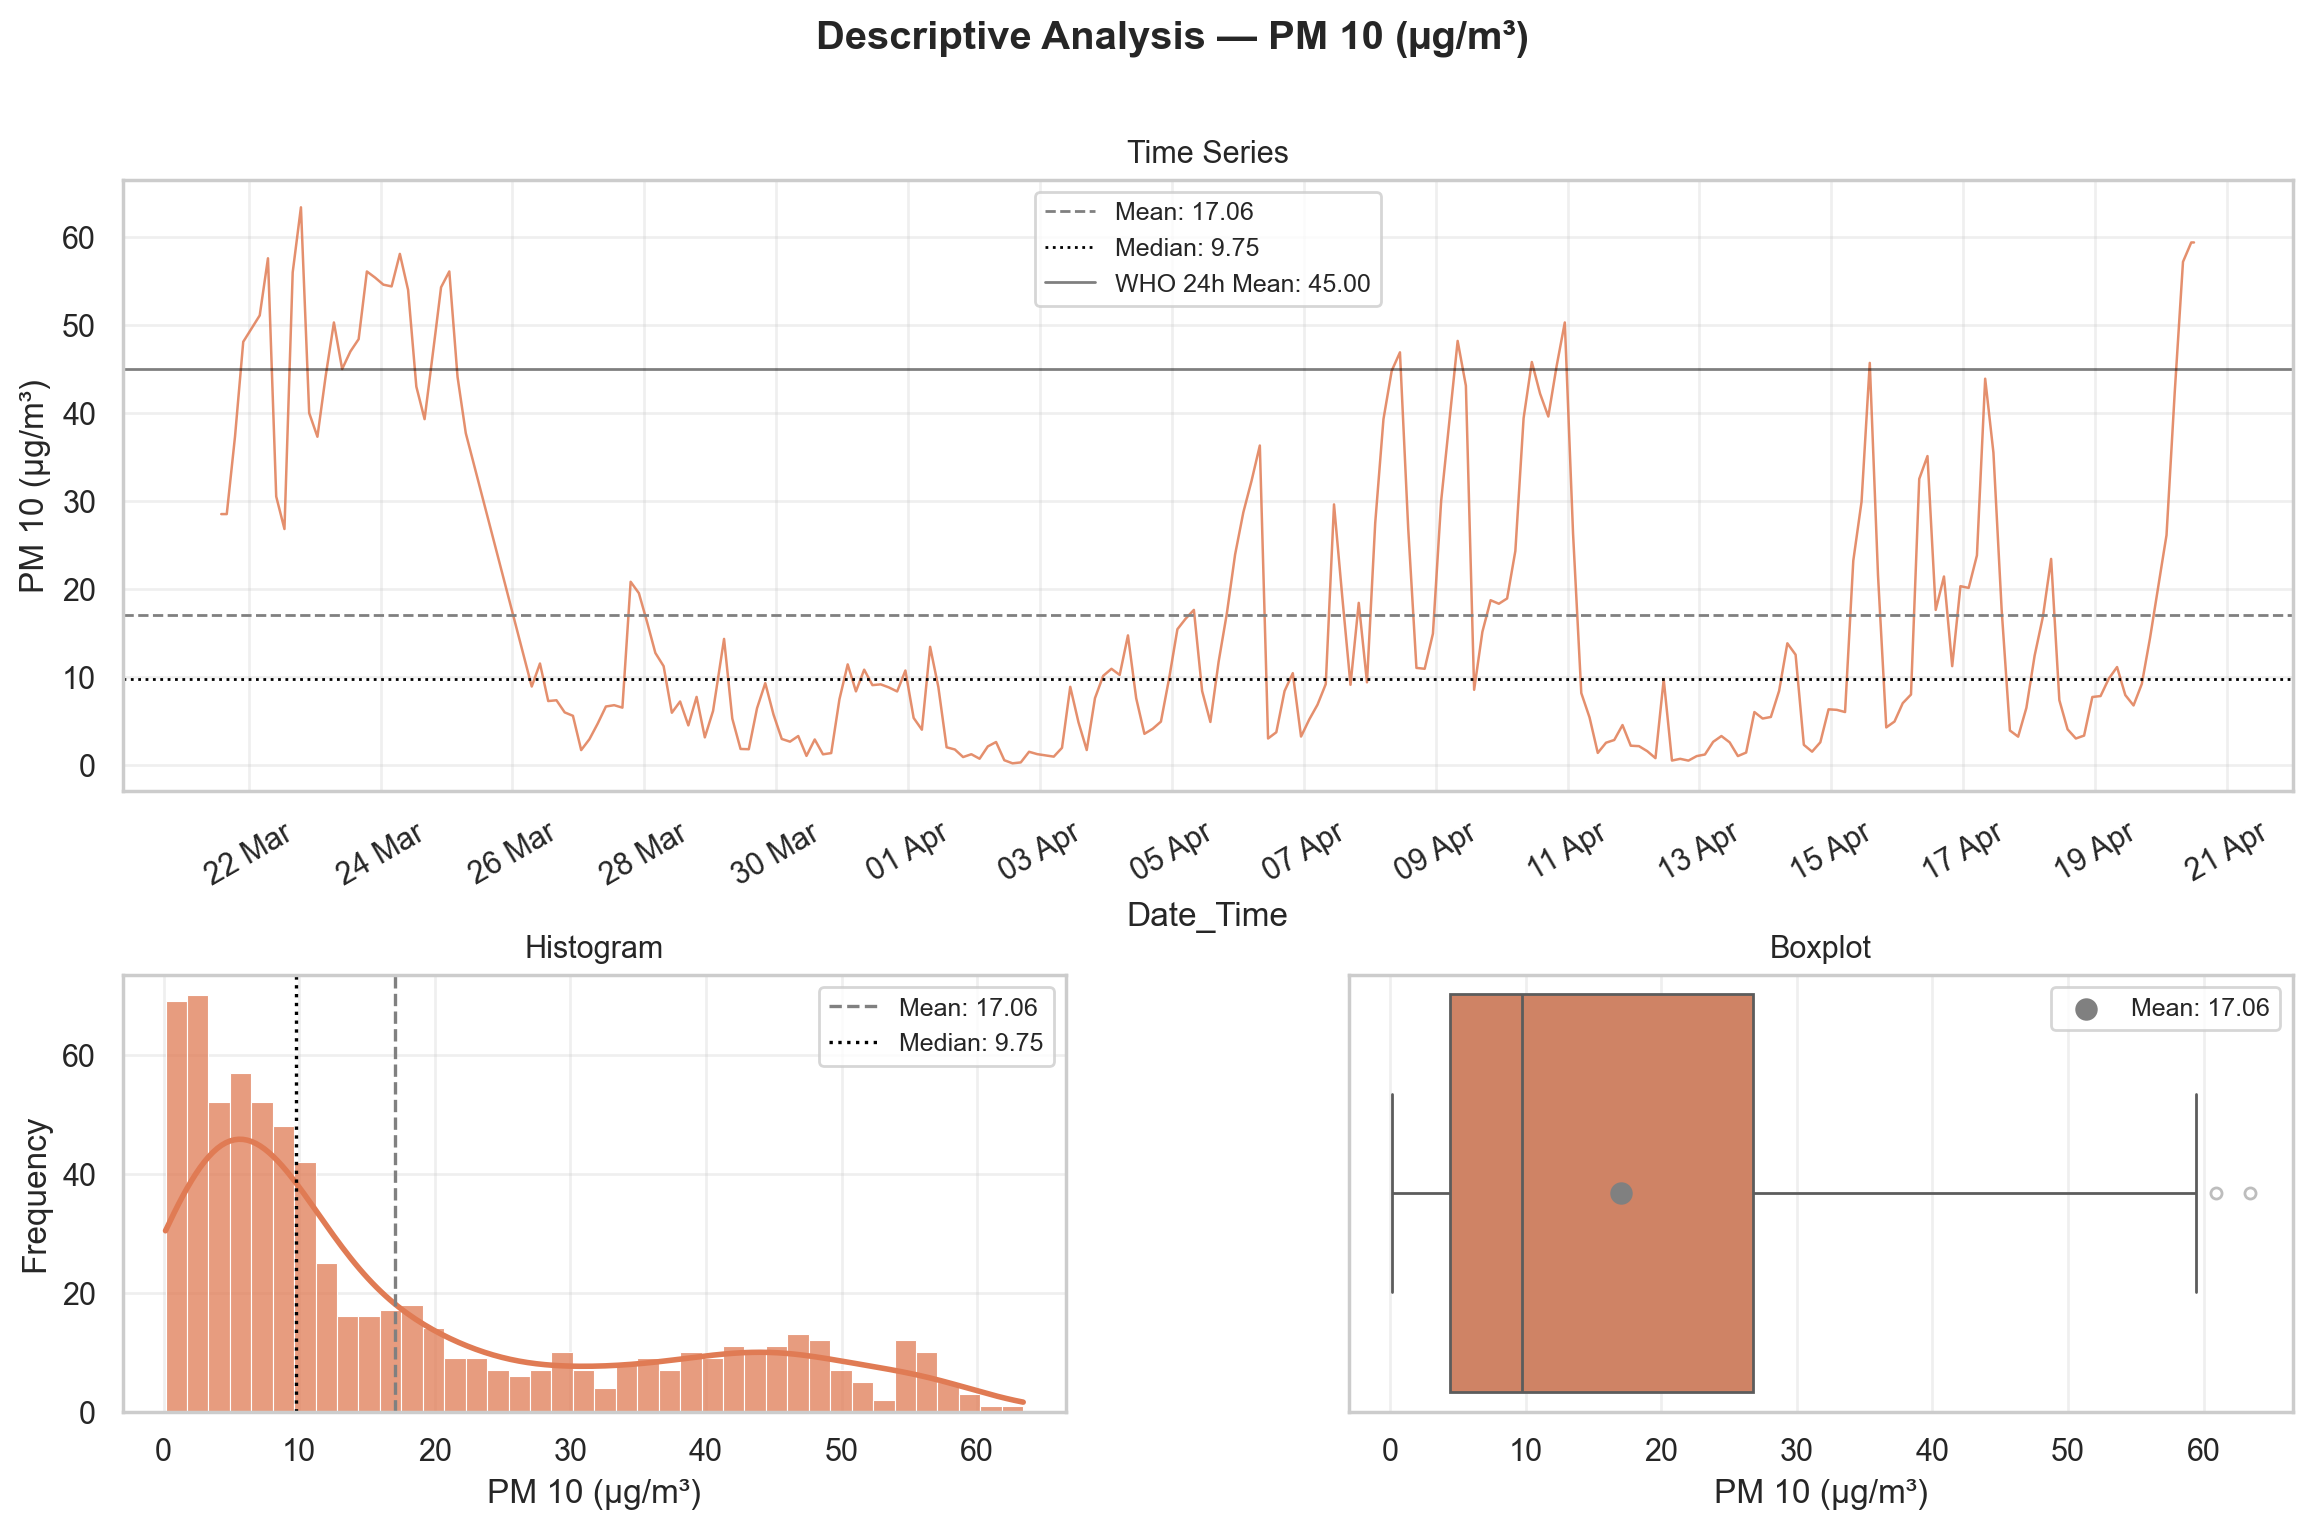

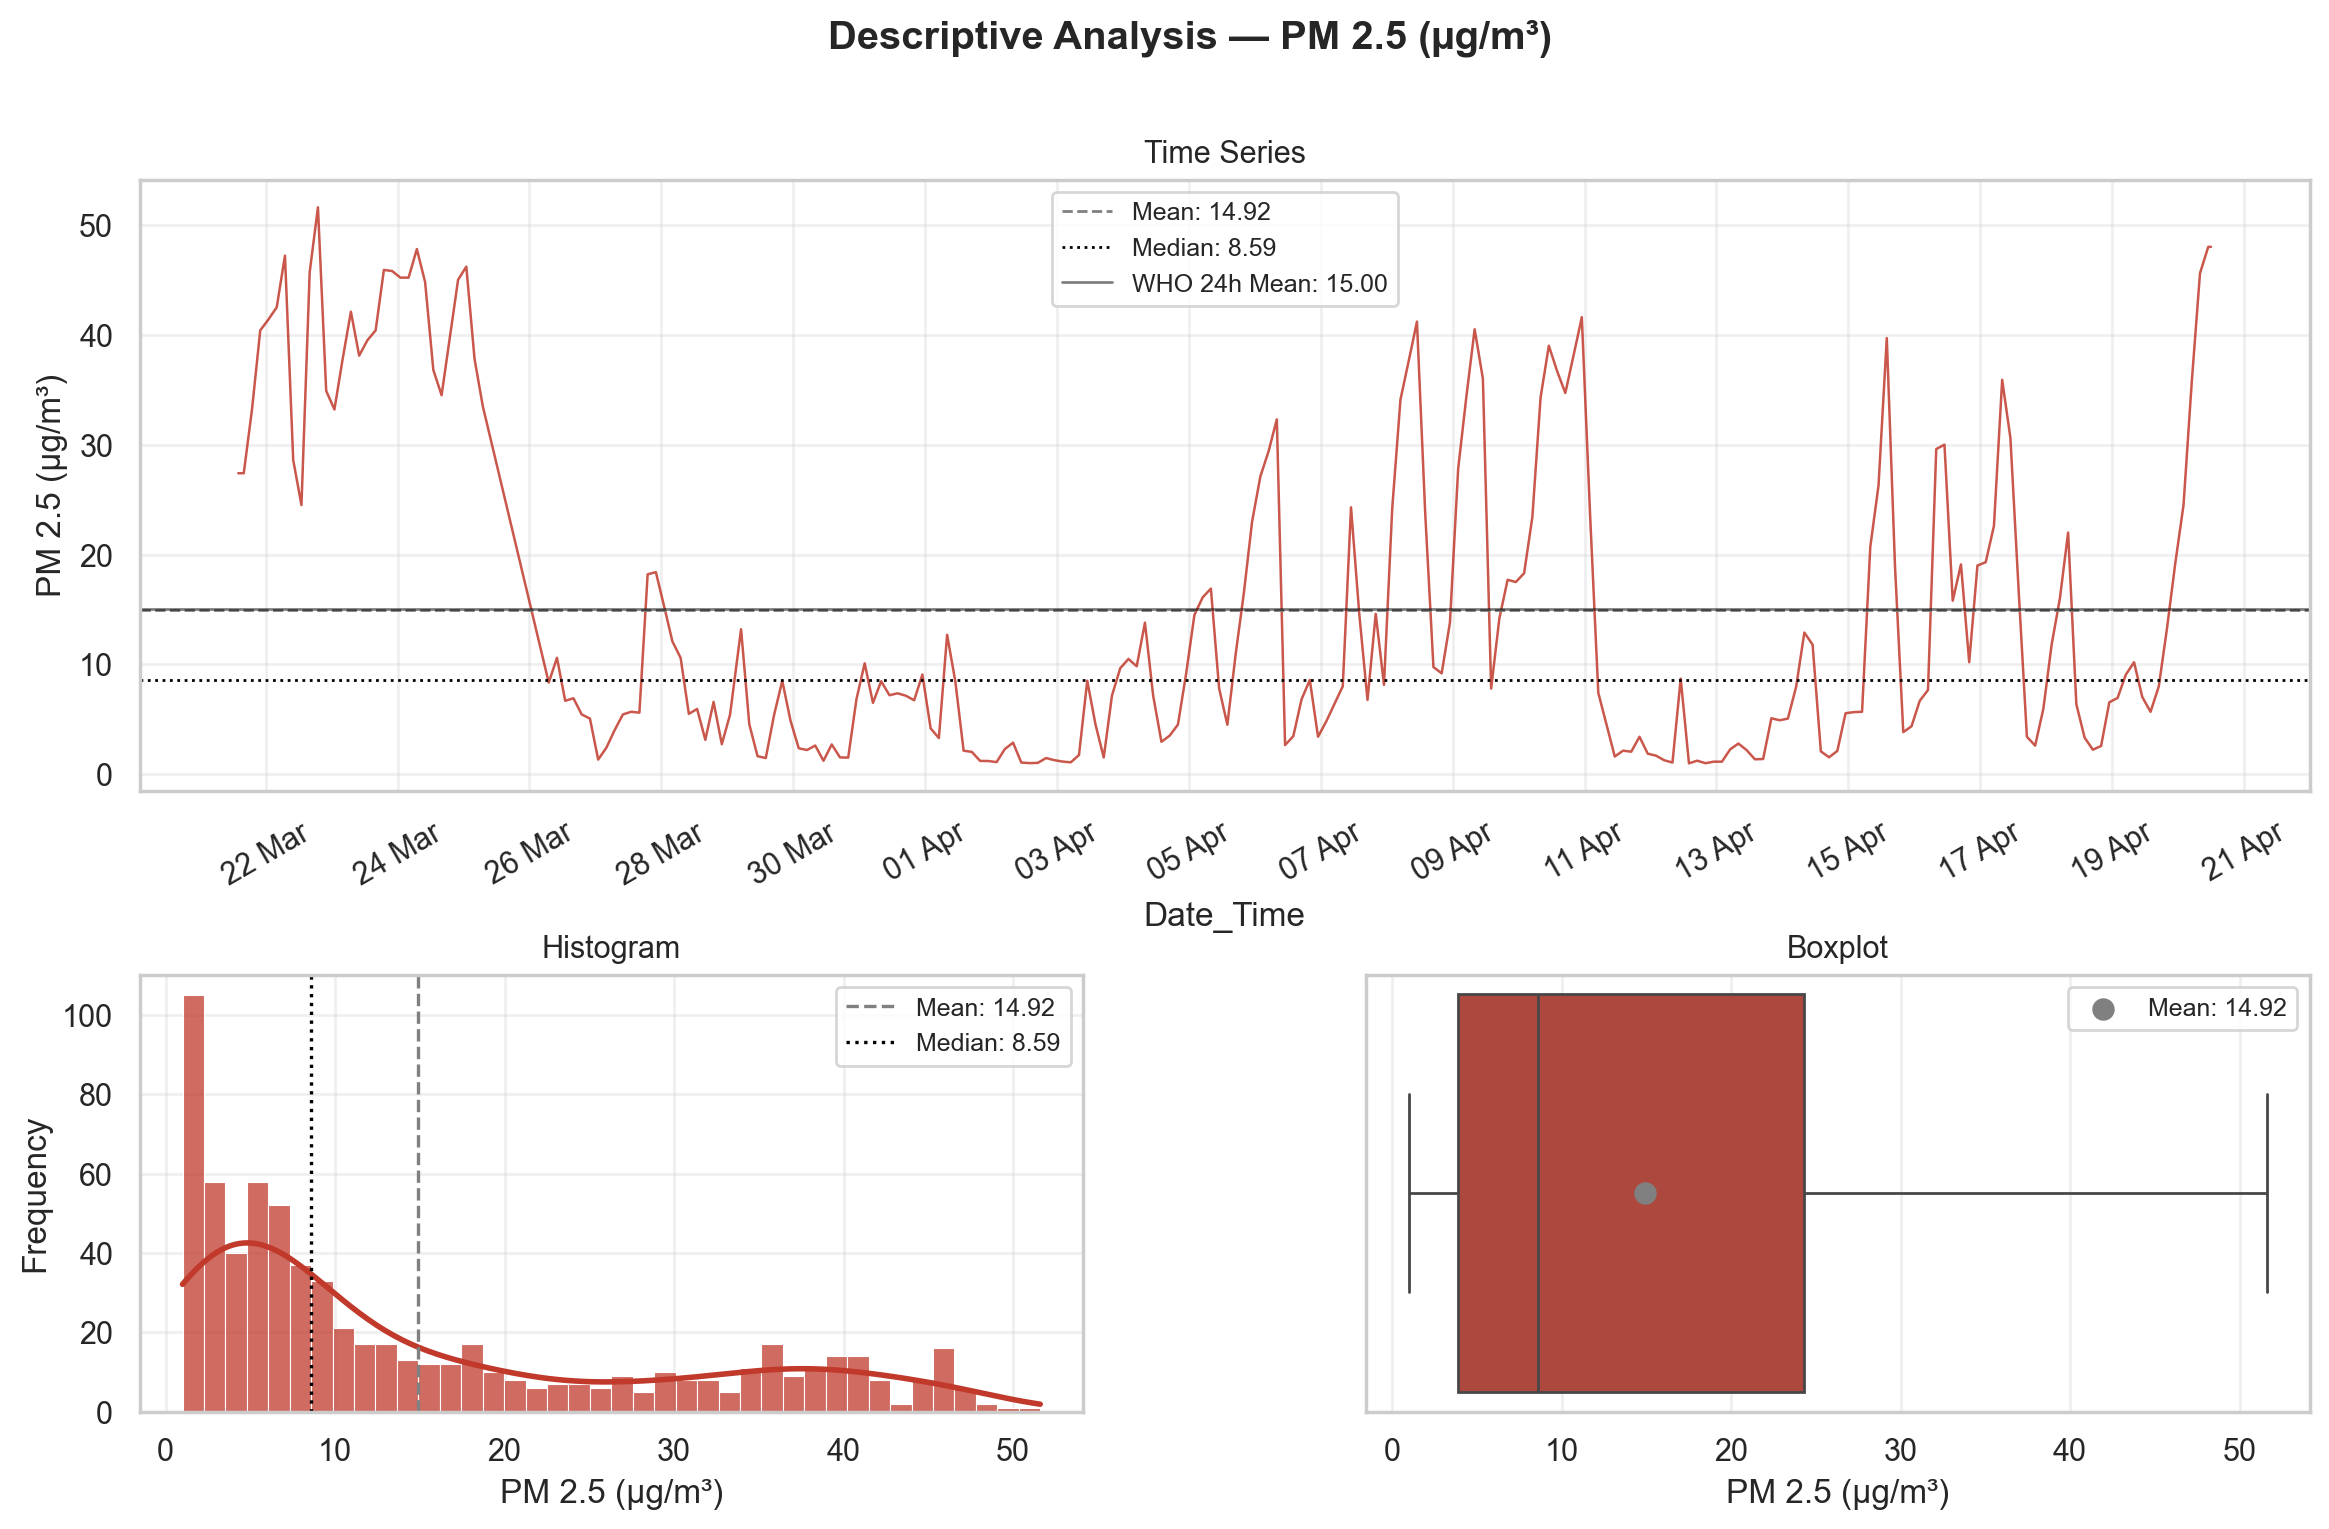

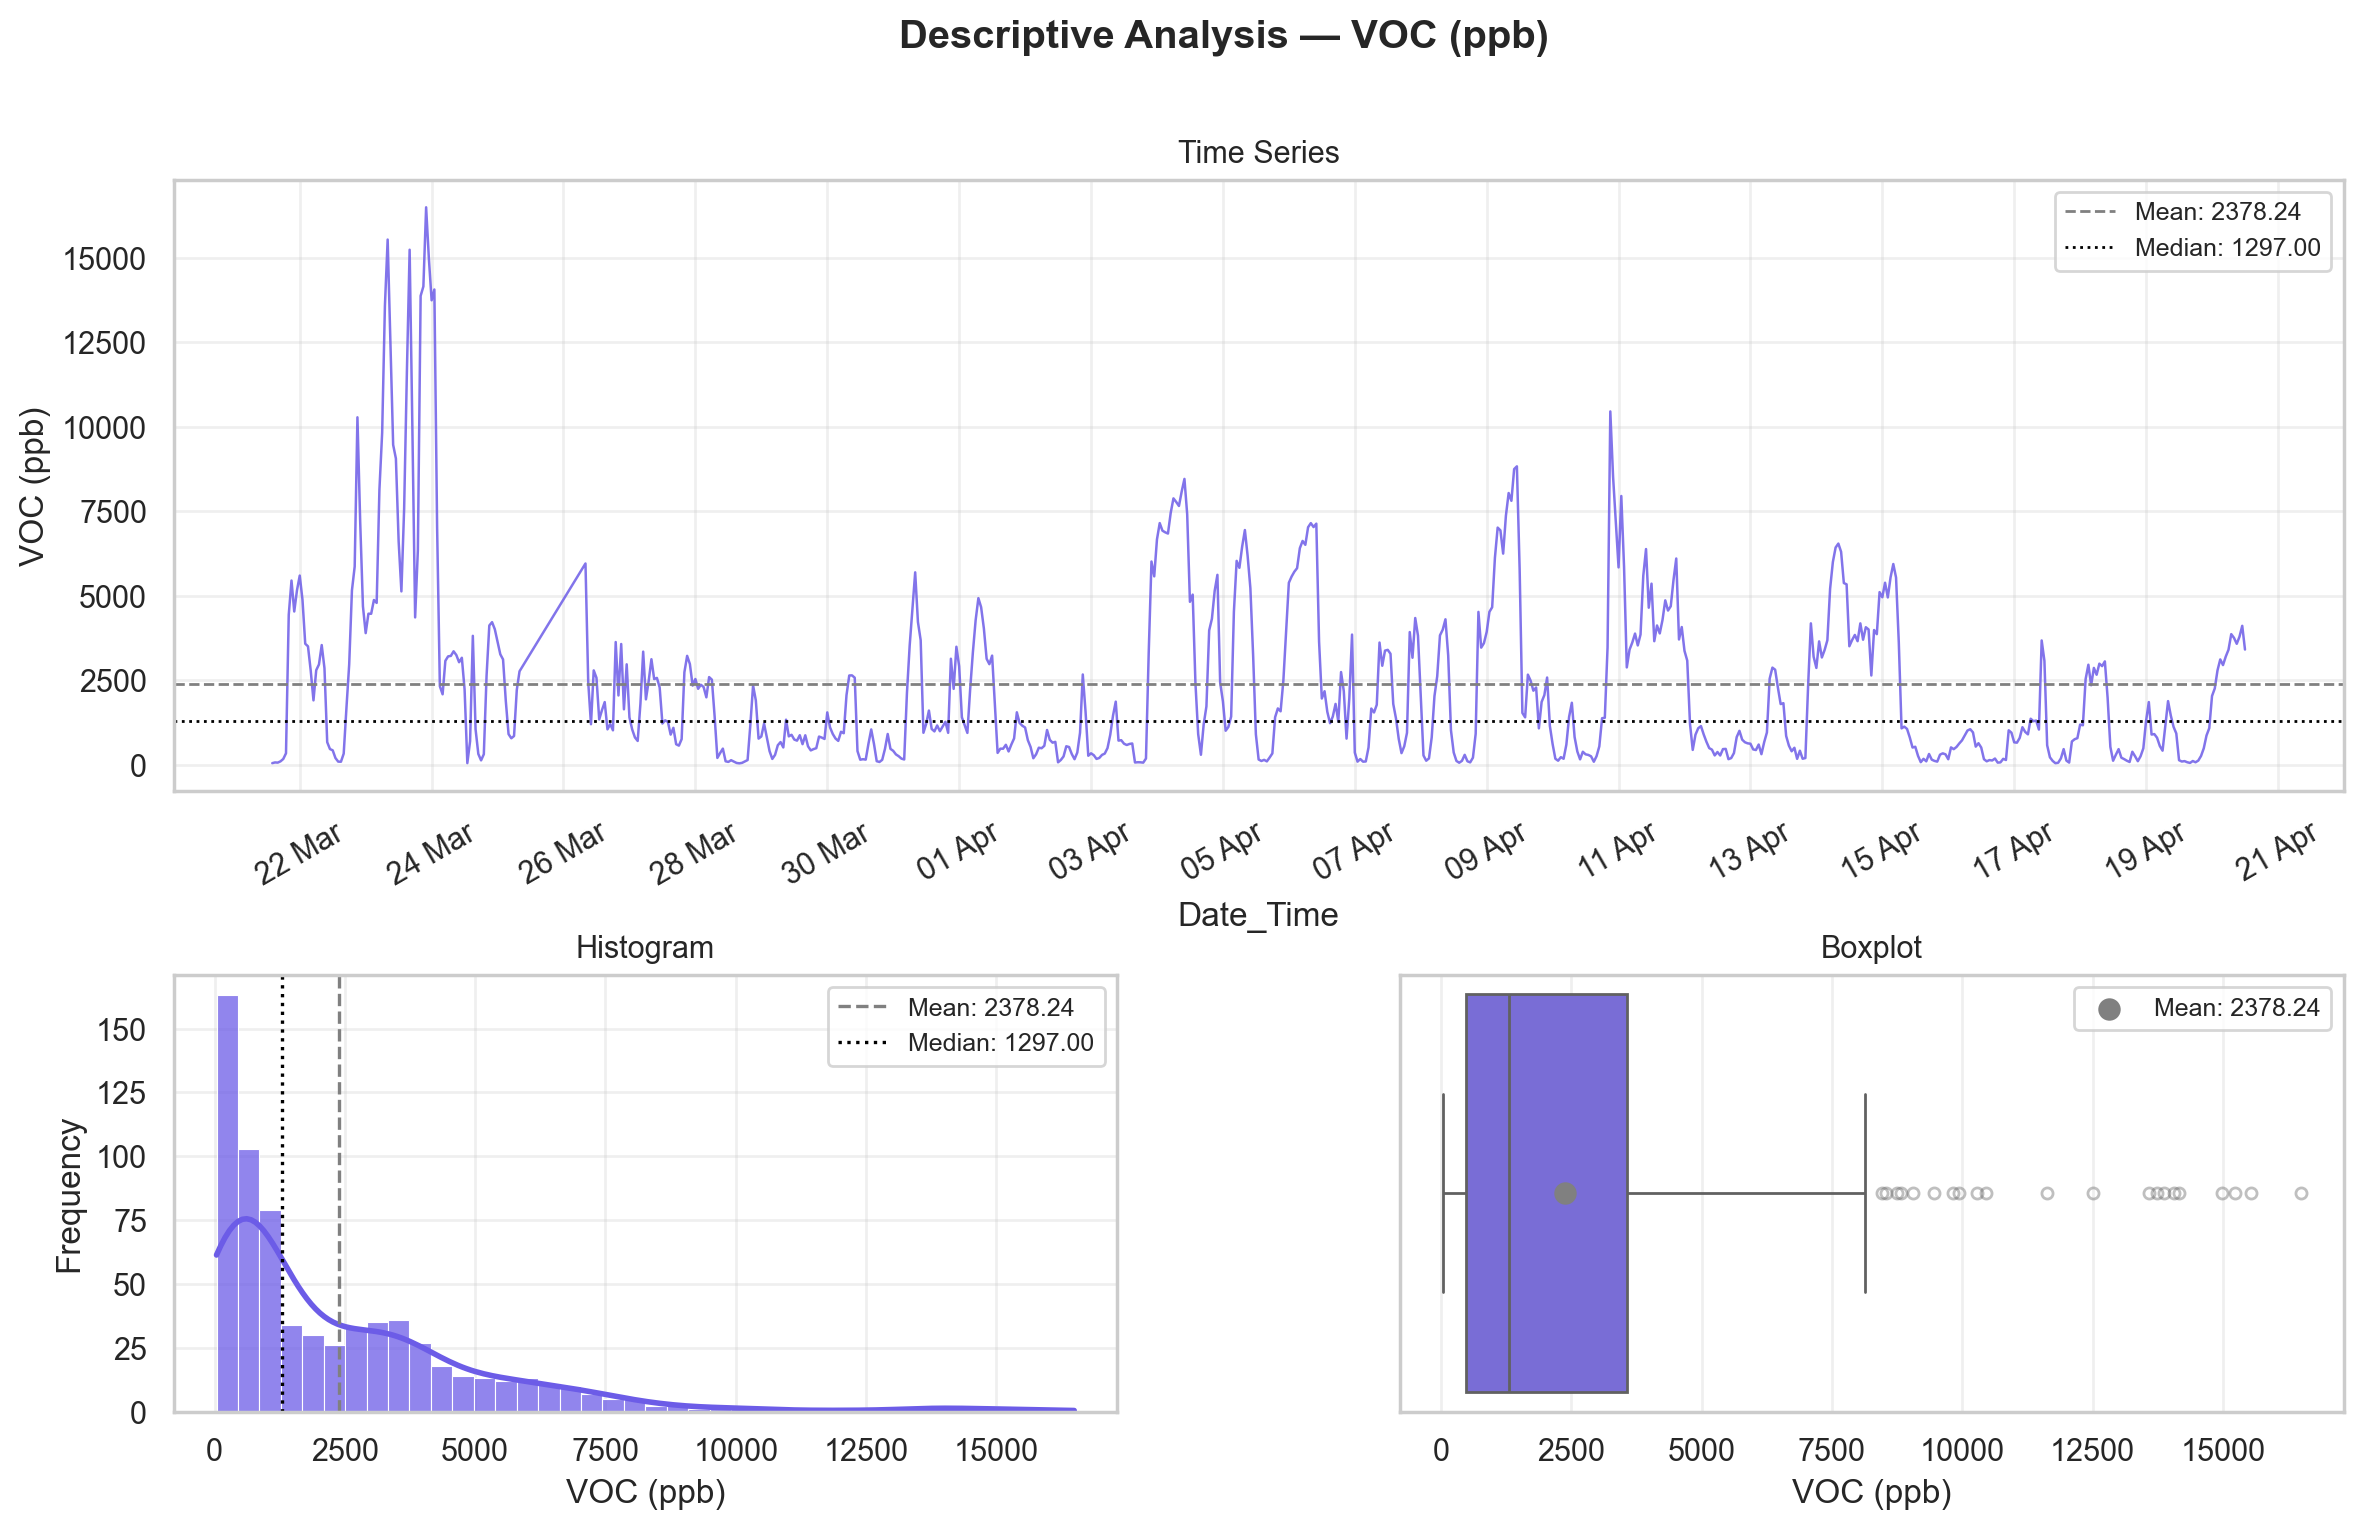

In [26]:
variables = {
    'PM10_ugm3': {'label': 'PM 10 (µg/m³)',  'color': '#E07B54', 'who_mean_level_24h': 45},
    'PM25_ugm3': {'label': 'PM 2.5 (µg/m³)', 'color': '#C0392B', 'who_mean_level_24h': 15},
    'VOC_ppb':    {'label': 'VOC (ppb)',       'color': '#6C5CE7'},
}

for col, info in variables.items():
    data = df[col]
    color = info['color']
    label = info['label']

    fig = plt.figure()
    fig.suptitle(f'Descriptive Analysis — {label}', fontweight='bold')

    # Layout: temporal series upside, histogram down left, boxplot down right
    gs = fig.add_gridspec(2, 2, height_ratios=[1.4, 1], hspace=0.35, wspace=0.3)
    ax_ts   = fig.add_subplot(gs[0, :])
    ax_hist = fig.add_subplot(gs[1, 0])
    ax_box  = fig.add_subplot(gs[1, 1], sharex=ax_hist)

    # --- Time Series ---
    sns.lineplot(x=data.index, y=data.values, ax=ax_ts, color=color, linewidth=0.9, alpha=0.85)
    ax_ts.axhline(data.mean(),   color='gray',  linestyle='--', linewidth=1,
                label=f'Mean: {data.mean():.2f}')
    ax_ts.axhline(data.median(), color='black', linestyle=':',  linewidth=1,
                label=f'Median: {data.median():.2f}')
    if info.get('who_mean_level_24h'):
        ax_ts.axhline(info['who_mean_level_24h'], color='black', linestyle='-',  linewidth=1, alpha=0.5, label=f"WHO 24h Mean: {info['who_mean_level_24h']:.2f}")

    ax_ts.set_title('Time Series', fontsize=11)
    ax_ts.set_ylabel(label)
    ax_ts.legend(fontsize=9)
    ax_ts.grid(axis='y', alpha=0.3)

    # Setup X axes ticks
    ax_ts.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # 1 tick every 2 days
    ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))  # Format: "21 Mar"
    ax_ts.tick_params(axis='x', rotation=30)

    # --- Histogram ---
    sns.histplot(data, bins=40, ax=ax_hist, color=color, alpha=0.75,
             edgecolor='white', linewidth=0.4, kde=True)
    ax_hist.axvline(data.mean(),   color='gray',  linestyle='--',
                    linewidth=1.2, label=f'Mean: {data.mean():.2f}')
    ax_hist.axvline(data.median(), color='black', linestyle=':',
                    linewidth=1.2, label=f'Median: {data.median():.2f}')
    ax_hist.set_title('Histogram', fontsize=11)
    ax_hist.set_xlabel(label)
    ax_hist.set_ylabel('Frequency')
    ax_hist.legend(fontsize=9)
    ax_hist.grid(axis='y', alpha=0.3)

    # --- Boxplot horizontal ---
    sns.boxplot(x=data, ax=ax_box, color=color, orient='h',
            width=0.4, flierprops=dict(marker='o', alpha=0.4, markersize=4))
    ax_box.scatter([data.mean()], [0], color='gray', zorder=5,
                s=50, label=f'Mean: {data.mean():.2f}')
    ax_box.set_title('Boxplot', fontsize=11)
    ax_box.set_xlabel(label)
    ax_box.set_yticks([])
    ax_box.legend(fontsize=9)
    ax_box.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'outputs/graphs/ts_hist_bp_{col}.png', dpi=200, bbox_inches='tight')

### 10.2.2 Target Variables: Visual Diagnostics & Insights

The visual evaluation of the target emission metrics reveals critical operational patterns, strongly influenced by workshop activity and regulatory thresholds. 

**World Health Organization (WHO) Daily Guidelines Baseline:**
- **PM10:** 45 µg/m³ (24-hour mean)
- **PM2.5:** 15 µg/m³ (24-hour mean)

#### 1. PM10 (Coarse Particulate Matter)
- **Time Series Dynamics:** The series displays two strictly distinct regimes. Between March 21 and March 25, concentrations sustain elevated levels, with acute peaks temporarily breaching the WHO 24-hour threshold of 45 µg/m³. Following this event, the baseline drops significantly. This structural shift correlates directly with intense heavy truck maintenance periods.
- **Distribution (Histogram):** Exhibits a bimodal distribution. This confirms two distinct statistical populations: active workshop periods and baseline atmospheric conditions. The active population right-skews the overall mean.
- **Outlier Density (Boxplot):** The high-emission regime in March expands the Interquartile Range (IQR). The boxplot accurately reflects a sustained operational reality rather than sensor anomalies.

#### 2. PM2.5 (Fine Particulate Matter)
- **Behavioral Similarity & Critical Violations:** The temporal behavior mirrors PM10, but the regulatory impact is drastically more severe. The entire March 21-25 operational regime continuously violates the WHO daily guideline of 15 µg/m³, reaching extreme peaks up to 51 µg/m³. This indicates a high-risk exposure environment during heavy vehicle presence.
- **Future Feature Engineering (Source Profiling):** The physical synchronicity between PM metrics enables the creation of a `PM2.5 / PM10 Ratio`. 
  - A ratio approaching `1.0` suggests combustion-driven sources (e.g., diesel exhaust).
  - A lower ratio points to mechanical suspension of coarse dust.

#### 3. VOC (Volatile Organic Compounds)
- **Time Series Dynamics:** An extreme emission spike synchronizes with the particulate matter peaks between March 22 and 24. This indicates a combined operational event (e.g., industrial painting combined with engine testing).
- **Circadian Volatility:** Unlike PM metrics, the VOC baseline remains highly volatile post-operation. Recurring spikes suggest a distinct behavioral mechanism, likely driven by circadian cycles (temperature and humidity acting as evaporation catalysts for stored chemicals).
- **Outlier Density:** The distribution is severely right-skewed. Values between 8,000 and 16,000 ppb register as statistical outliers but represent true acute chemical exposure events.

### 10.2.3 Comparative Temporal Dynamics: PM10 vs. VOC

To evaluate source correlation, the temporal trajectories of particulate and chemical emissions are overlaid. `PM2.5` is excluded from this visualization due to its near-perfect collinearity with `PM10`, preventing visual redundancy. 

Because `PM10` (µg/m³) and `VOC` (ppb) operate on fundamentally different mathematical scales, a direct graphical comparison is invalid. A `MinMaxScaler` is applied to transform both vectors onto a standardized `[0, 1]` continuum. 

**Analytical Objective:** This normalized overlay isolates the temporal geometry of the emission peaks. It tests the hypothesis of source synchronicity: determining whether physical particulates and volatile chemicals share a strictly coupled operational origin, or if they exhibit divergent patterns indicative of independent emission mechanisms.

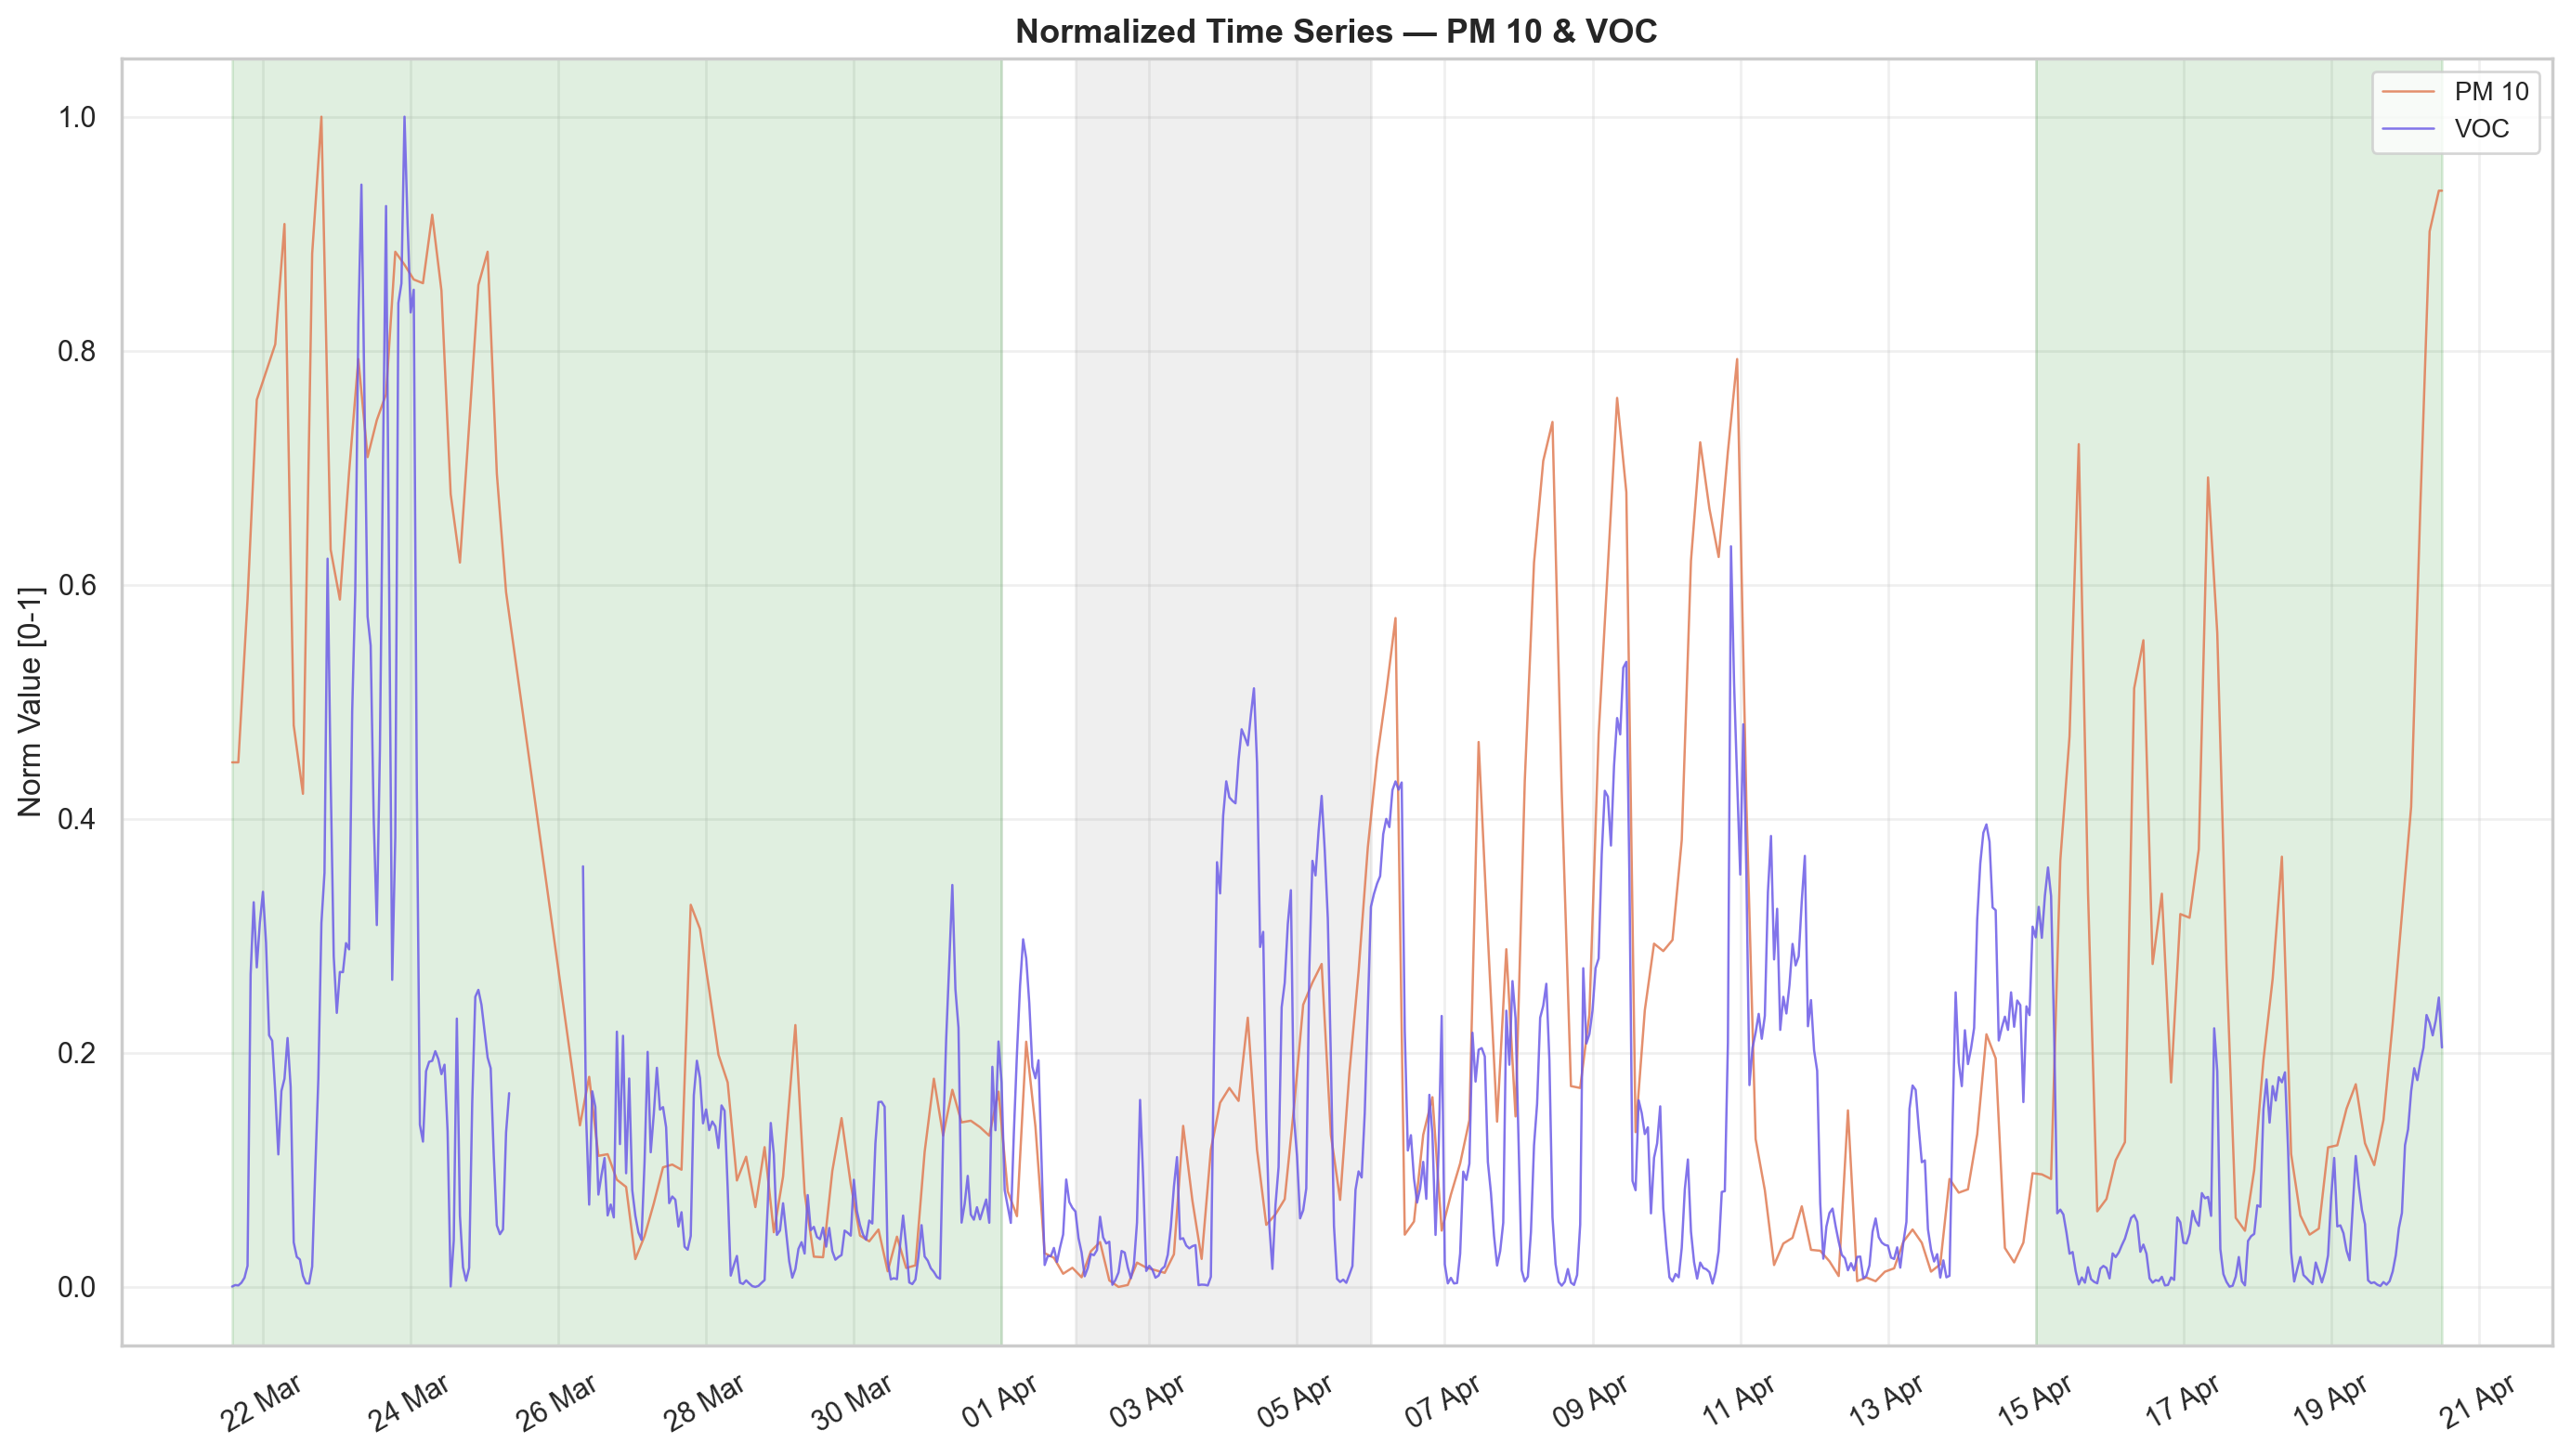

In [27]:
cols = ['PM10_ugm3', 'VOC_ppb']

# Normalizar
scaler = MinMaxScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(df[cols]),
    index=df.index,
    columns=cols
)

# Plot
fig, ax = plt.subplots()

colores = {'PM10_ugm3': '#E07B54', 'VOC_ppb': '#6C5CE7'}
labels  = {'PM10_ugm3': 'PM 10', 'VOC_ppb': 'VOC'}

for col in cols:
    ax.plot(df_norm.index, df_norm[col],
            color=colores[col], label=labels[col],
            linewidth=0.9, alpha=0.85)

# Truck Shadow
truck = df['Truck_Presence']
with_truck = False
start   = None
for t, val in truck.items():
    if val and not with_truck:
        start   = t
        with_truck = True
    elif not val and with_truck:
        ax.axvspan(start, t, alpha=0.12, color='green', label='_nolegend_')
        with_truck = False
if with_truck:
    ax.axvspan(start, truck.index[-1], alpha=0.12, color='green')

# Easter Holiday Shadow
easter_period = df['Easter_Holiday']
with_holiday = False
start   = None
for t, val in easter_period.items():
    if val and not with_holiday:
        start   = t
        with_holiday = True
    elif not val and with_holiday:
        ax.axvspan(start, t, alpha=0.12, color='grey', label='_nolegend_')
        with_holiday = False
if with_holiday:
    ax.axvspan(start, easter_period.index[-1], alpha=0.12, color='grey')

handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor='green', alpha=0.3, label='Truck Presence'))
ax.legend(handles=handles, fontsize=9)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.tick_params(axis='x', rotation=30)
ax.set_title('Normalized Time Series — PM 10 & VOC', fontsize=13, fontweight='bold')
ax.set_ylabel('Norm Value [0-1]')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/graphs/normalized_ts_PM_VOC.png', dpi=200, bbox_inches='tight')

### 10.2.4 Comparative Dynamics Insights: Source Coupling & Decoupling

The normalized overlay of PM10 and VOC reveals both shared operational origins and distinct external influences.

- **Particulate Collinearity (PM10 & PM2.5):** The particulate metrics exhibit near-perfect correlation. They share an identical physical origin and behave as a single analytical entity throughout the dataset.
- **Operational Coupling (The Multiplier Effect):** During periods of truck presence (e.g., March 21-25), VOC and PM vectors strictly synchronize, reaching their maximum dataset values simultaneously. This confirms that active workshop operations act as a massive emission multiplier, emitting both physical particulates (exhaust, mechanical dust) and chemical volatiles (solvents, unburned hydrocarbons) concurrently.
- **The Decoupling Phenomenon (External Sources):** Complete decoupling occurs during specific intervals, most notably during the Easter Holiday. In this period, PM remains flat while VOC exhibits severe spikes. This strongly suggests an external, non-operational source. Given the holiday context, these standalone VOC peaks are highly indicative of surrounding highway traffic (vacation departure/return flows) infiltrating the sensor array.
- **High-Frequency Intra-day Volatility:** VOC displays a highly volatile, high-frequency oscillatory pattern within single 24-hour cycles, whereas PM behavior is slower and more persistent. This intra-day VOC volatility points to a dual-driver mechanism: 
  1. **Traffic Rush Hours:** Diurnal traffic volume fluctuations.
  2. **Circadian Thermodynamics:** Daily temperature and humidity cycles acting as catalysts for the continuous evaporation of stored workshop chemicals.

## 10.3 Temporal Distribution & Segment Analysis

To isolate recurring patterns and identify peak exposure windows, the target pollutants are evaluated across three categorical temporal dimensions:

- **Circadian Profile:** Hourly aggregation to visualize the 24-hour diurnal cycle, identifying peaks linked to rush hours and workshop startup.
- **Operational Segments (`Time_Segment`):** Distributional analysis across predefined periods (Morning, Afternoon, Night) to quantify exposure levels during active vs. inactive shifts.
- **Weekly Cycle (`Day_of_Week`):** Comparative analysis between business days and weekends to isolate the workshop's contribution from the regional atmospheric background.

**Analytical Strategy:** Boxplots are utilized to observe not only the central tendency but also the density of extreme events (outliers) within each temporal bucket.

In [28]:
df.columns

Index(['PM10_ugm3', 'PM25_ugm3', 'VOC_ppb', 'Wind_Dir', 'Wind_Speed_kmH',
       'Temperature_º', 'Humidity_%', 'Rain_mmh', 'Hour', 'Day_of_Week',
       'Time_Segment', 'Truck_Presence', 'Easter_Holiday'],
      dtype='str')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29568\3930605749.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(days_short)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29568\3930605749.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(days_short)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29568\3930605749.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('outputs/graphs/time_segment_PM10_VOC.png', dpi=200, bbox_inches='tight')
c:\Users\Usuario\code\air_quality\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


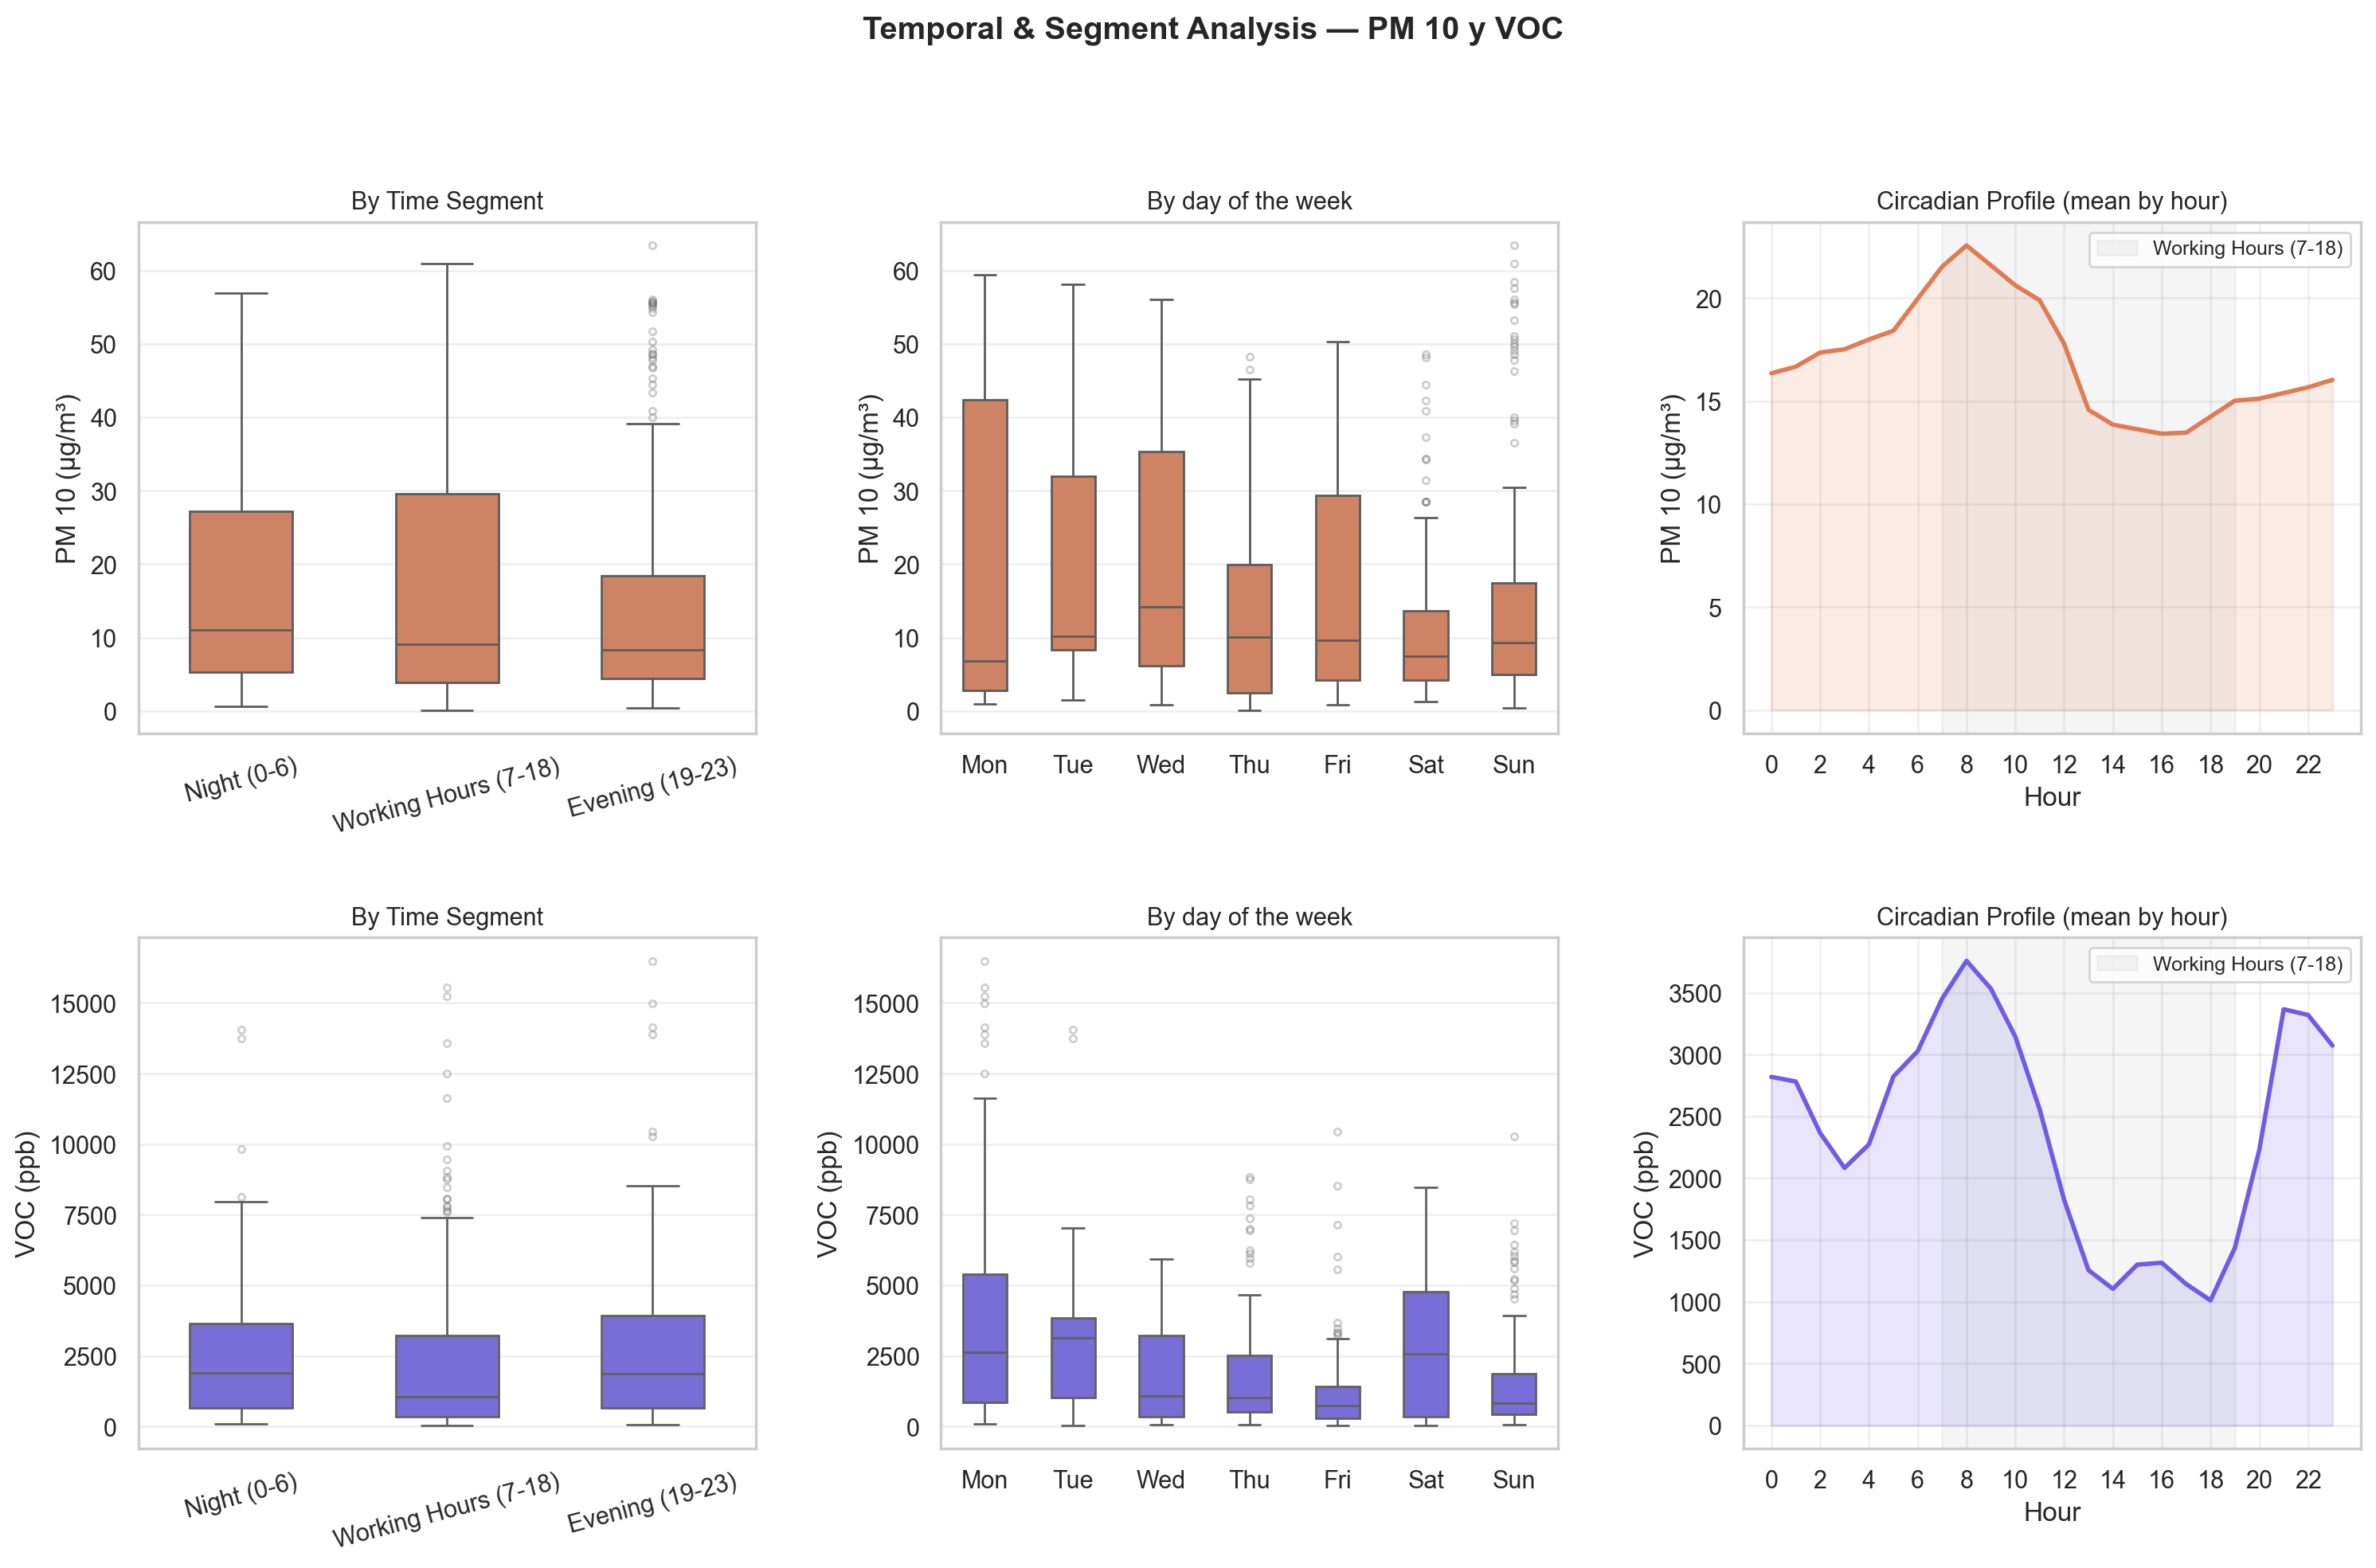

In [29]:
variables = {
    'PM10_ugm3': {'label': 'PM 10 (µg/m³)', 'color': '#E07B54'},
    'VOC_ppb':    {'label': 'VOC (ppb)',      'color': '#6C5CE7'},
}

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
days_short = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(
    nrows=2, ncols=3,
    figsize=(18, 10),
    gridspec_kw={'wspace': 0.3, 'hspace': 0.4}
)

fig.suptitle('Temporal & Segment Analysis — PM 10 y VOC', fontweight='bold', y=1.01)

for row, (col, meta) in enumerate(variables.items()):
    color = meta['color']
    label = meta['label']
    data  = df[[col, 'Time_Segment', 'Day_of_Week', 'Hour']].dropna()

    # --- Col 0: Boxplot by time segment ---
    ax = axes[row, 0]
    sns.boxplot(
        data=data, x='Time_Segment', y=col, ax=ax,
        order=['Night (0-6)', 'Working Hours (7-18)', 'Evening (19-23)'],
        color=color, width=0.5, flierprops=dict(marker='o', alpha=0.3, markersize=3)
    )
    ax.set_title('By Time Segment', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

    # --- Col 1: Boxplot by day of week ---
    ax = axes[row, 1]
    sns.boxplot(
        data=data, x='Day_of_Week', y=col, ax=ax,
        order=days_order, color=color, width=0.5,
        flierprops=dict(marker='o', alpha=0.3, markersize=3)
    )
    ax.set_title('By day of the week', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.set_xticklabels(days_short)
    ax.grid(axis='y', alpha=0.3)

    # --- Col 2: Circadian Profile ---
    ax = axes[row, 2]
    perfil = data.groupby('Hour')[col].mean()
    ax.plot(perfil.index, perfil.values, color=color, linewidth=2)
    ax.fill_between(perfil.index, perfil.values, alpha=0.15, color=color)
    ax.axvspan(7, 19, alpha=0.08, color='gray', label='Working Hours (7-18)')
    ax.set_title('Circadian Profile (mean by hour)', fontsize=11)
    ax.set_xlabel('Hour')
    ax.set_ylabel(label)
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.savefig('outputs/graphs/time_segment_PM10_VOC.png', dpi=200, bbox_inches='tight')
plt.show()

### 10.3.1 Temporal Diagnostics & Source Apportionment Hypotheses

The temporal decomposition reveals that emission metrics are driven by a complex interplay between facility operations, adjacent highway traffic, and atmospheric physics.

#### 1. PM10 
- **Source Overlap:** The distributional geometry indicates at least two overlapping emission drivers.
- **Circadian Rhythm (Traffic Influence):** The circadian profile displays a peak between 07:00-10:00 and a secondary rebound post-20:00. These specific windows align perfectly with adjacent highway rush-hour commuting.
- **Weekly Cycle (Workshop Operations):** The sustained elevated median levels from Monday to Friday, followed by a sharp decay on Saturday, map strictly to the workshop's active operational calendar. The slight concentration rebound on Sunday reflects pure leisure highway traffic, entirely independent of industrial activity.
- **Nighttime Anomalies (Atmospheric Inversion):** The presence of severe outlier events during the 'Night (0-6)' segment does not necessarily imply unrecorded nocturnal work. In environmental telemetry, this is a classic signature of nighttime atmospheric inversion—the boundary layer compresses as temperatures drop, preventing vertical mixing and artificially concentrating residual surface particulates.

#### 2. VOC 
- **Bimodal Circadian Rhythm:** Exhibits a strict bimodal profile with acute, symmetrical peaks at 08:00 and 20:00. This temporal geometry is highly characteristic of vehicular exhaust (highway rush hours).
- **Weekly Cycle Variance (The Weekend Anomaly):** Monday registers the highest overall density, suggesting either chemical accumulation within the facility over the closed weekend or intense operational startup protocols. Crucially, Saturday registers as the second-highest day in outlier density. Since the workshop is largely inactive on Saturdays, this validates the hypothesis that external highway traffic (weekend travel flows) is a massive, independent VOC driver.

## 10.4 Operational Impact Assessment: The Truck Multiplier Effect

To definitively isolate the workshop's emission footprint from the regional background (such as highway traffic), we execute a comparative evaluation using the `Truck_Presence` categorical flag. This analysis triangulates the operational impact across three visual dimensions:

1. **Baseline Shift (Boxplots):** Quantifies the absolute increase in the median concentration and the density of extreme outlier events when heavy vehicles are actively serviced.
2. **Circadian Distortion (Diurnal Overlay):** Splits the 24-hour baseline into two distinct populations (Active Workshop vs. Inactive Workshop). This allows us to observe how industrial operations distort the natural background rhythm and amplify the traffic-induced peaks.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29568\918963267.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29568\918963267.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Without Truck', 'With Truck'])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29568\918963267.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29568\918963267.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabe

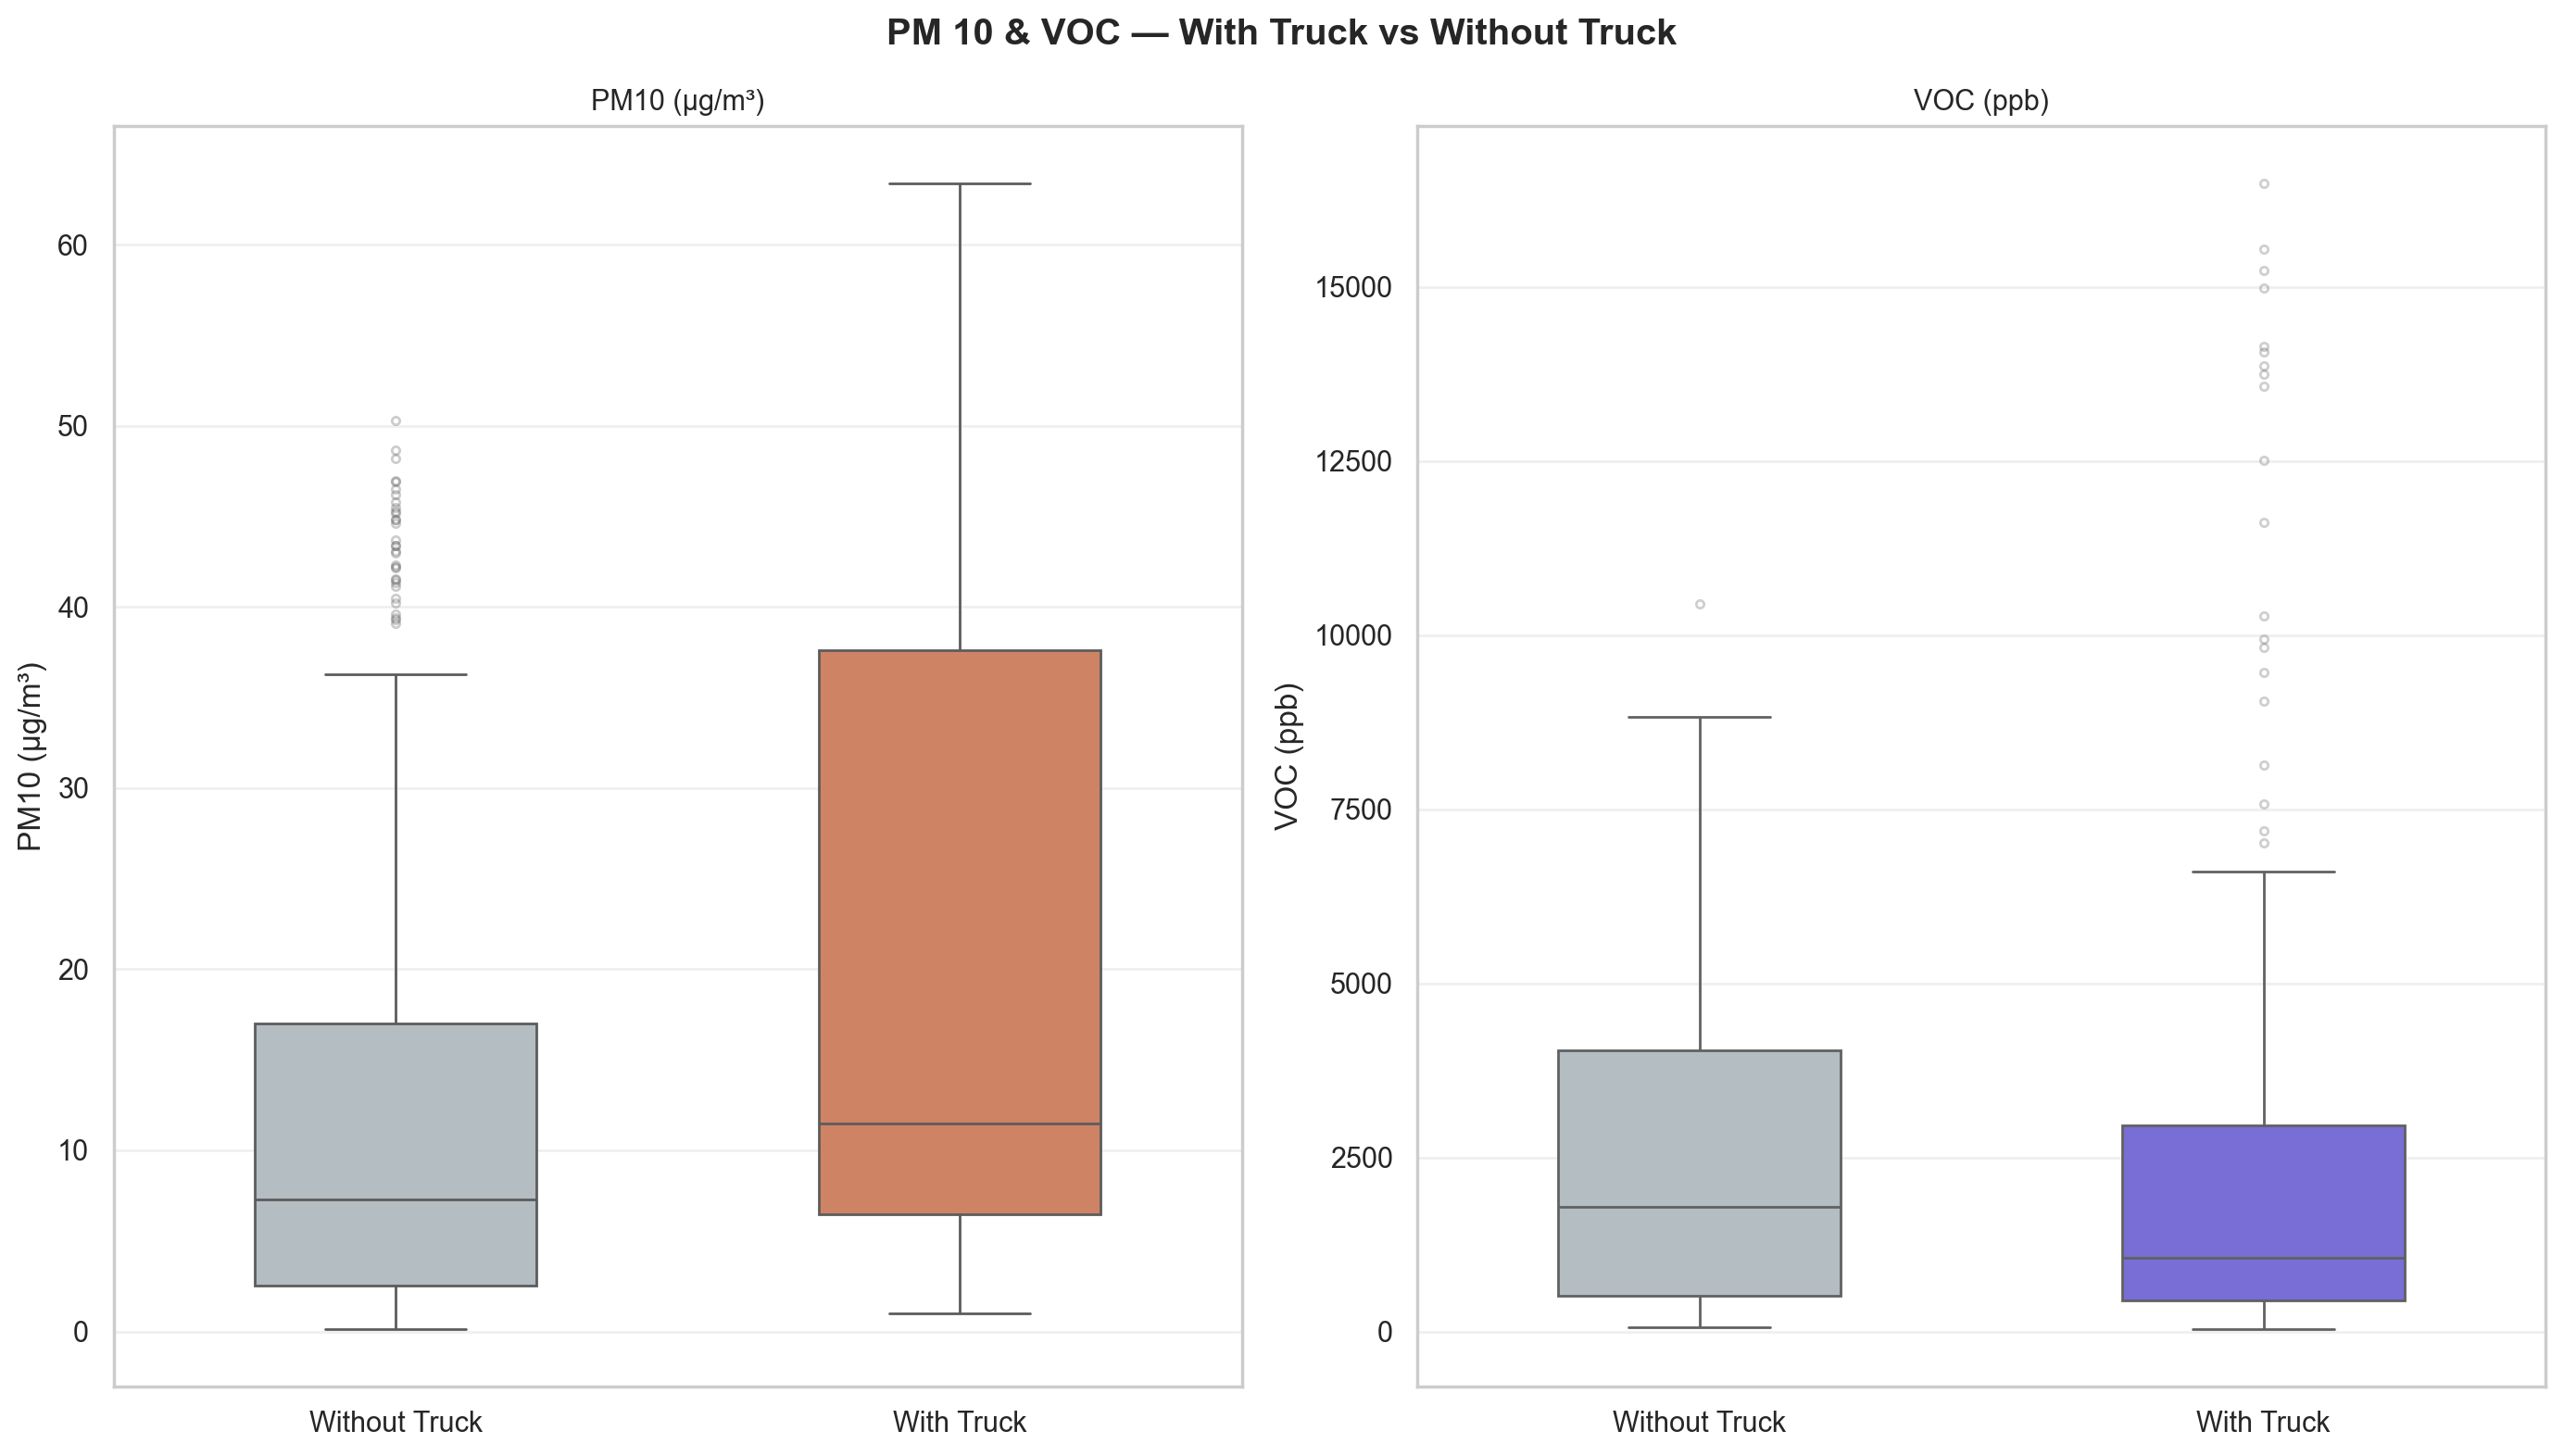

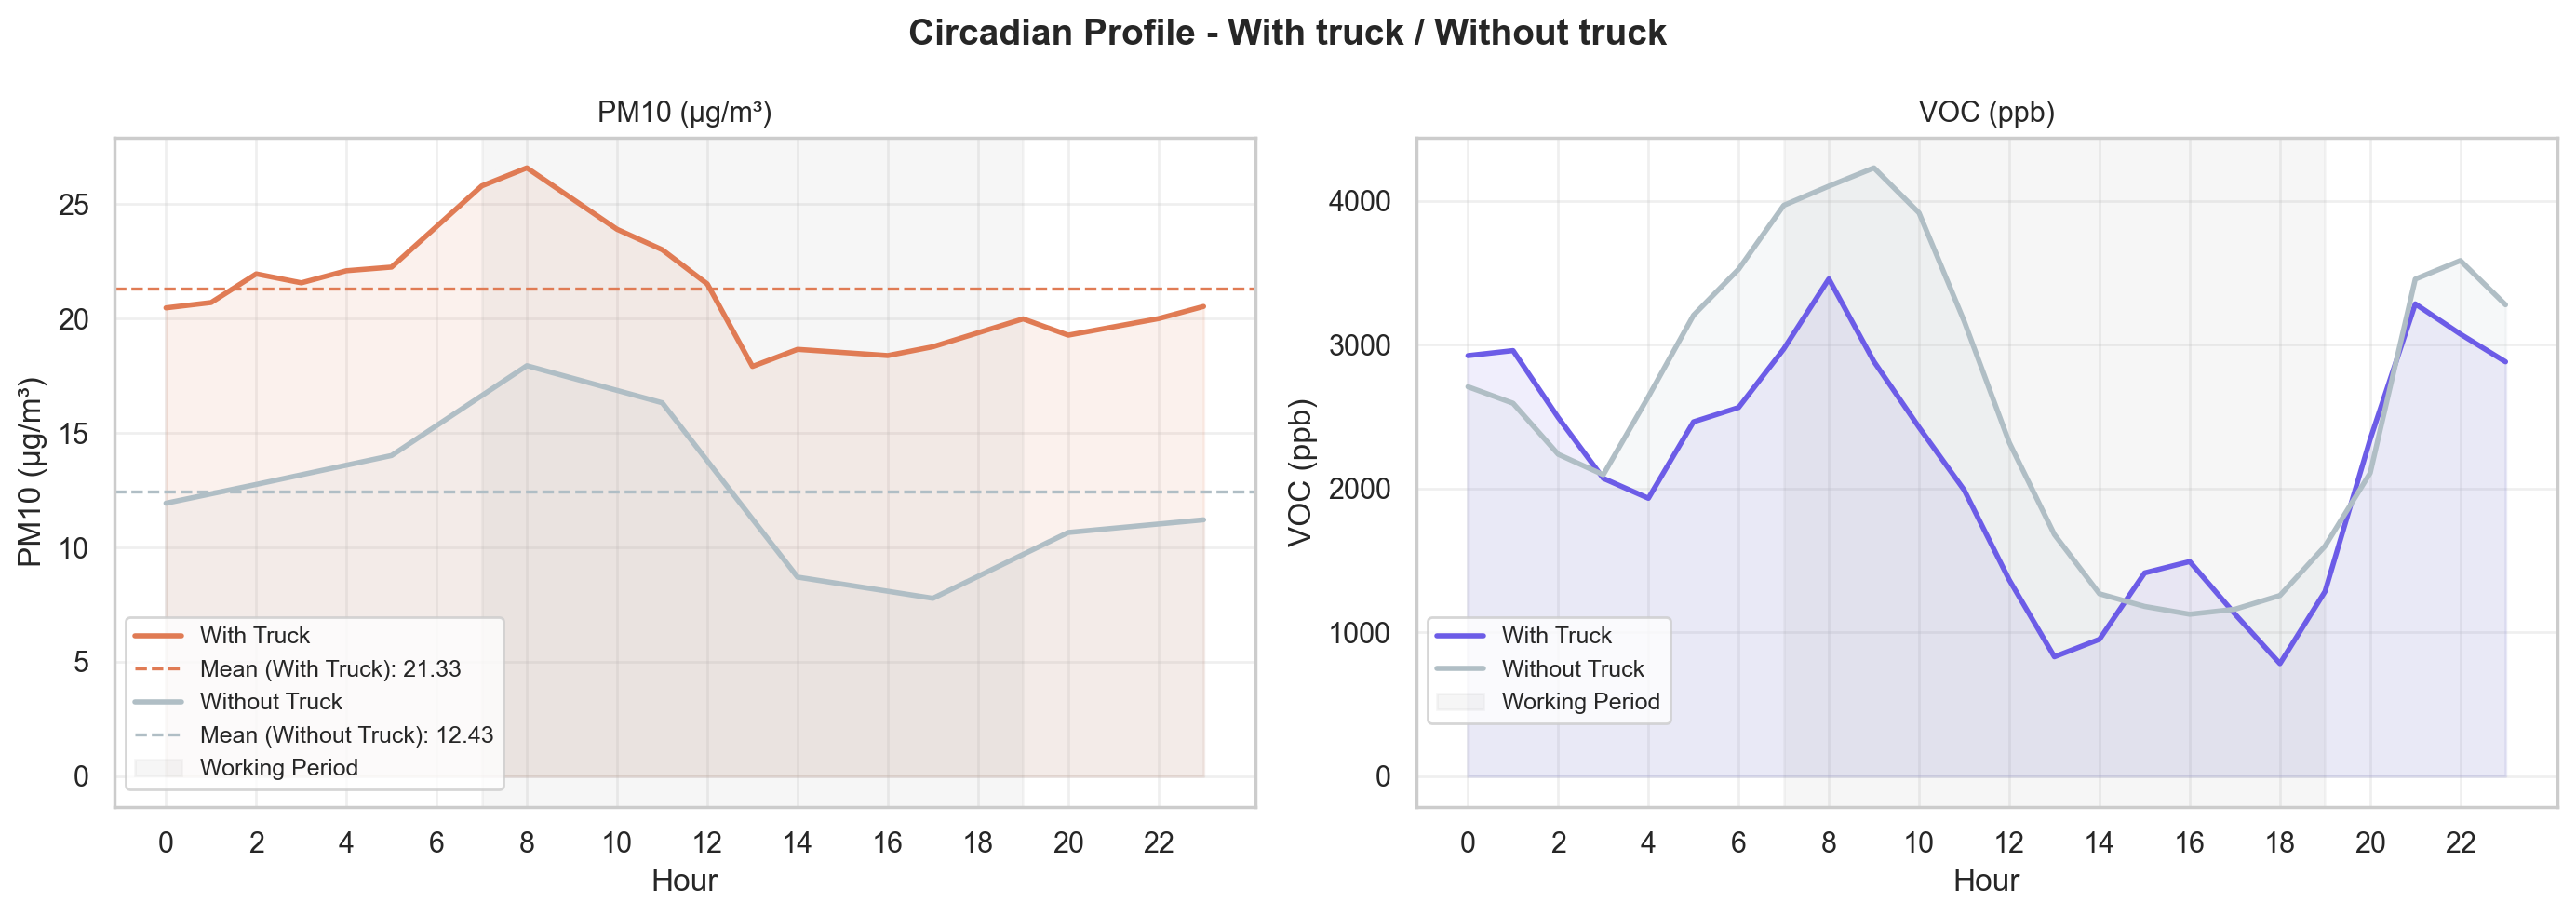

In [30]:
variables = ['PM10_ugm3', 'VOC_ppb']
colores   = {'PM10_ugm3': '#E07B54', 'VOC_ppb': '#6C5CE7'}
labels    = {'PM10_ugm3': 'PM10 (µg/m³)', 'VOC_ppb': 'VOC (ppb)'}

# ── 1. Boxplot Truck yes/no ──
fig, axes = plt.subplots(1, 2)
fig.suptitle('PM 10 & VOC — With Truck vs Without Truck', fontweight='bold')

for ax, col in zip(axes, variables):
    sns.boxplot(
        data=df, x='Truck_Presence', y=col, ax=ax,
        palette={'True': colores[col], 'False': '#B0BEC5'},
        width=0.5, flierprops=dict(marker='o', alpha=0.3, markersize=3)
    )
    ax.set_title(labels[col], fontsize=11)
    ax.set_xlabel('')
    ax.set_xticklabels(['Without Truck', 'With Truck'])
    ax.set_ylabel(labels[col])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/graphs/boxplot_truck.png', dpi=200, bbox_inches='tight')
plt.show()


# ── 2. Circadian Profile with/out truck ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Circadian Profile - With truck / Without truck',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes, variables):
    for truck_val, etiqueta, color in [
        (True,  'With Truck',  colores[col]),
        (False, 'Without Truck',  '#B0BEC5')
    ]:
        perfil = df[df['Truck_Presence'] == truck_val].groupby('Hour')[col].mean()
        ax.plot(perfil.index, perfil.values,
                color=color, linewidth=2, label=etiqueta)
        ax.fill_between(perfil.index, perfil.values, alpha=0.1, color=color)

        if col == 'PM10_ugm3':
            mean_val = df[df['Truck_Presence'] == truck_val][col].mean()
            ax.axhline(mean_val, color=color, linestyle='--', linewidth=1.2,
                       label=f'Mean ({etiqueta}): {mean_val:.2f}')

    ax.axvspan(7, 19, alpha=0.07, color='gray', label='Working Period')
    ax.set_title(labels[col], fontsize=11)
    ax.set_xlabel('Hour')
    ax.set_ylabel(labels[col])
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(0, 0.3))
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/graphs/circadian_truck.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.4.1 Operational Impact Insights: The Truck Multiplier

The comparative evaluation utilizing the `Truck_Presence` flag reveals a strict behavioral divergence between physical particulates and chemical volatiles.

#### 1. PM10 (Coarse Particulate Matter)
- **Baseline Amplification (Boxplot):** Heavy vehicle presence acts as a direct emission multiplier. The median concentration shifts from ~9 µg/m³ to ~15 µg/m³, and the Interquartile Range (IQR) expands massively. This variance reflects the fluctuating intensity of specific daily maintenance tasks. Without trucks, the environment reverts to a low, stable baseline.
- **Continuous Saturation (Circadian Profile):** Truck presence elevates PM10 levels systematically across all 24 hours, not strictly during the 07:00–18:00 operational window. The structural shape of the curve (08:00 peak, midday trough, nocturnal rebound) remains identical in both scenarios. This proves the baseline highway traffic pattern is permanent, but the active workshop adds a constant, overlapping saturation layer.
- **Regulatory Context (WHO Benchmark):** When considering the circadian averages, PM10 concentrations in both scenarios remain consistently below the 24-hour guideline value of 45 µg/m³ established by the World Health Organization. This suggests that, despite the clear relative increase associated with truck activity, absolute exposure levels do not reach critical thresholds under typical conditions. However, this comparison should be interpreted cautiously, as the guideline refers to fully integrated 24-hour exposure rather than averaged hourly profiles.

#### 2. VOC (Volatile Organic Compounds)
- **Counterintuitive Decoupling (Boxplot):** Contrary to initial assumptions, truck presence does not uniformly drive VOCs. The median concentration with trucks is statistically similar to the baseline without trucks. Furthermore, the extreme outliers (13,000–16,000 ppb) exist across both populations, suggesting alternate source dominance.
- **Traffic Dominance (Circadian Profile):** The circadian overlay confirms this decoupling. The acute 08:00–10:00 morning peak is significantly more pronounced when the workshop is empty. This definitively isolates adjacent highway traffic as the primary driver of morning VOC spikes. The flatter daytime profile during truck presence suggests that general maintenance does not inherently spike VOCs, or these specific periods align with meteorological conditions that suppress chemical volatilization.

#### General Conclusion
Heavy vehicle maintenance exerts a clear, demonstrable, and continuous upward pressure on physical particulate matter (PM10). However, even under truck-active conditions, the resulting concentrations remain within internationally recognized safety margins based on WHO guidelines. Conversely, general VOC emissions are decoupled from standard truck presence and are heavily masked by external drivers (highway traffic, thermodynamics).

WHO Violations Report (Days):
PM 10 (>45) WITH truck: 3 | WITHOUT truck: 0
PM 2.5 (>15) WITH truck: 9 | WITHOUT truck: 4
--------------------------------------------------


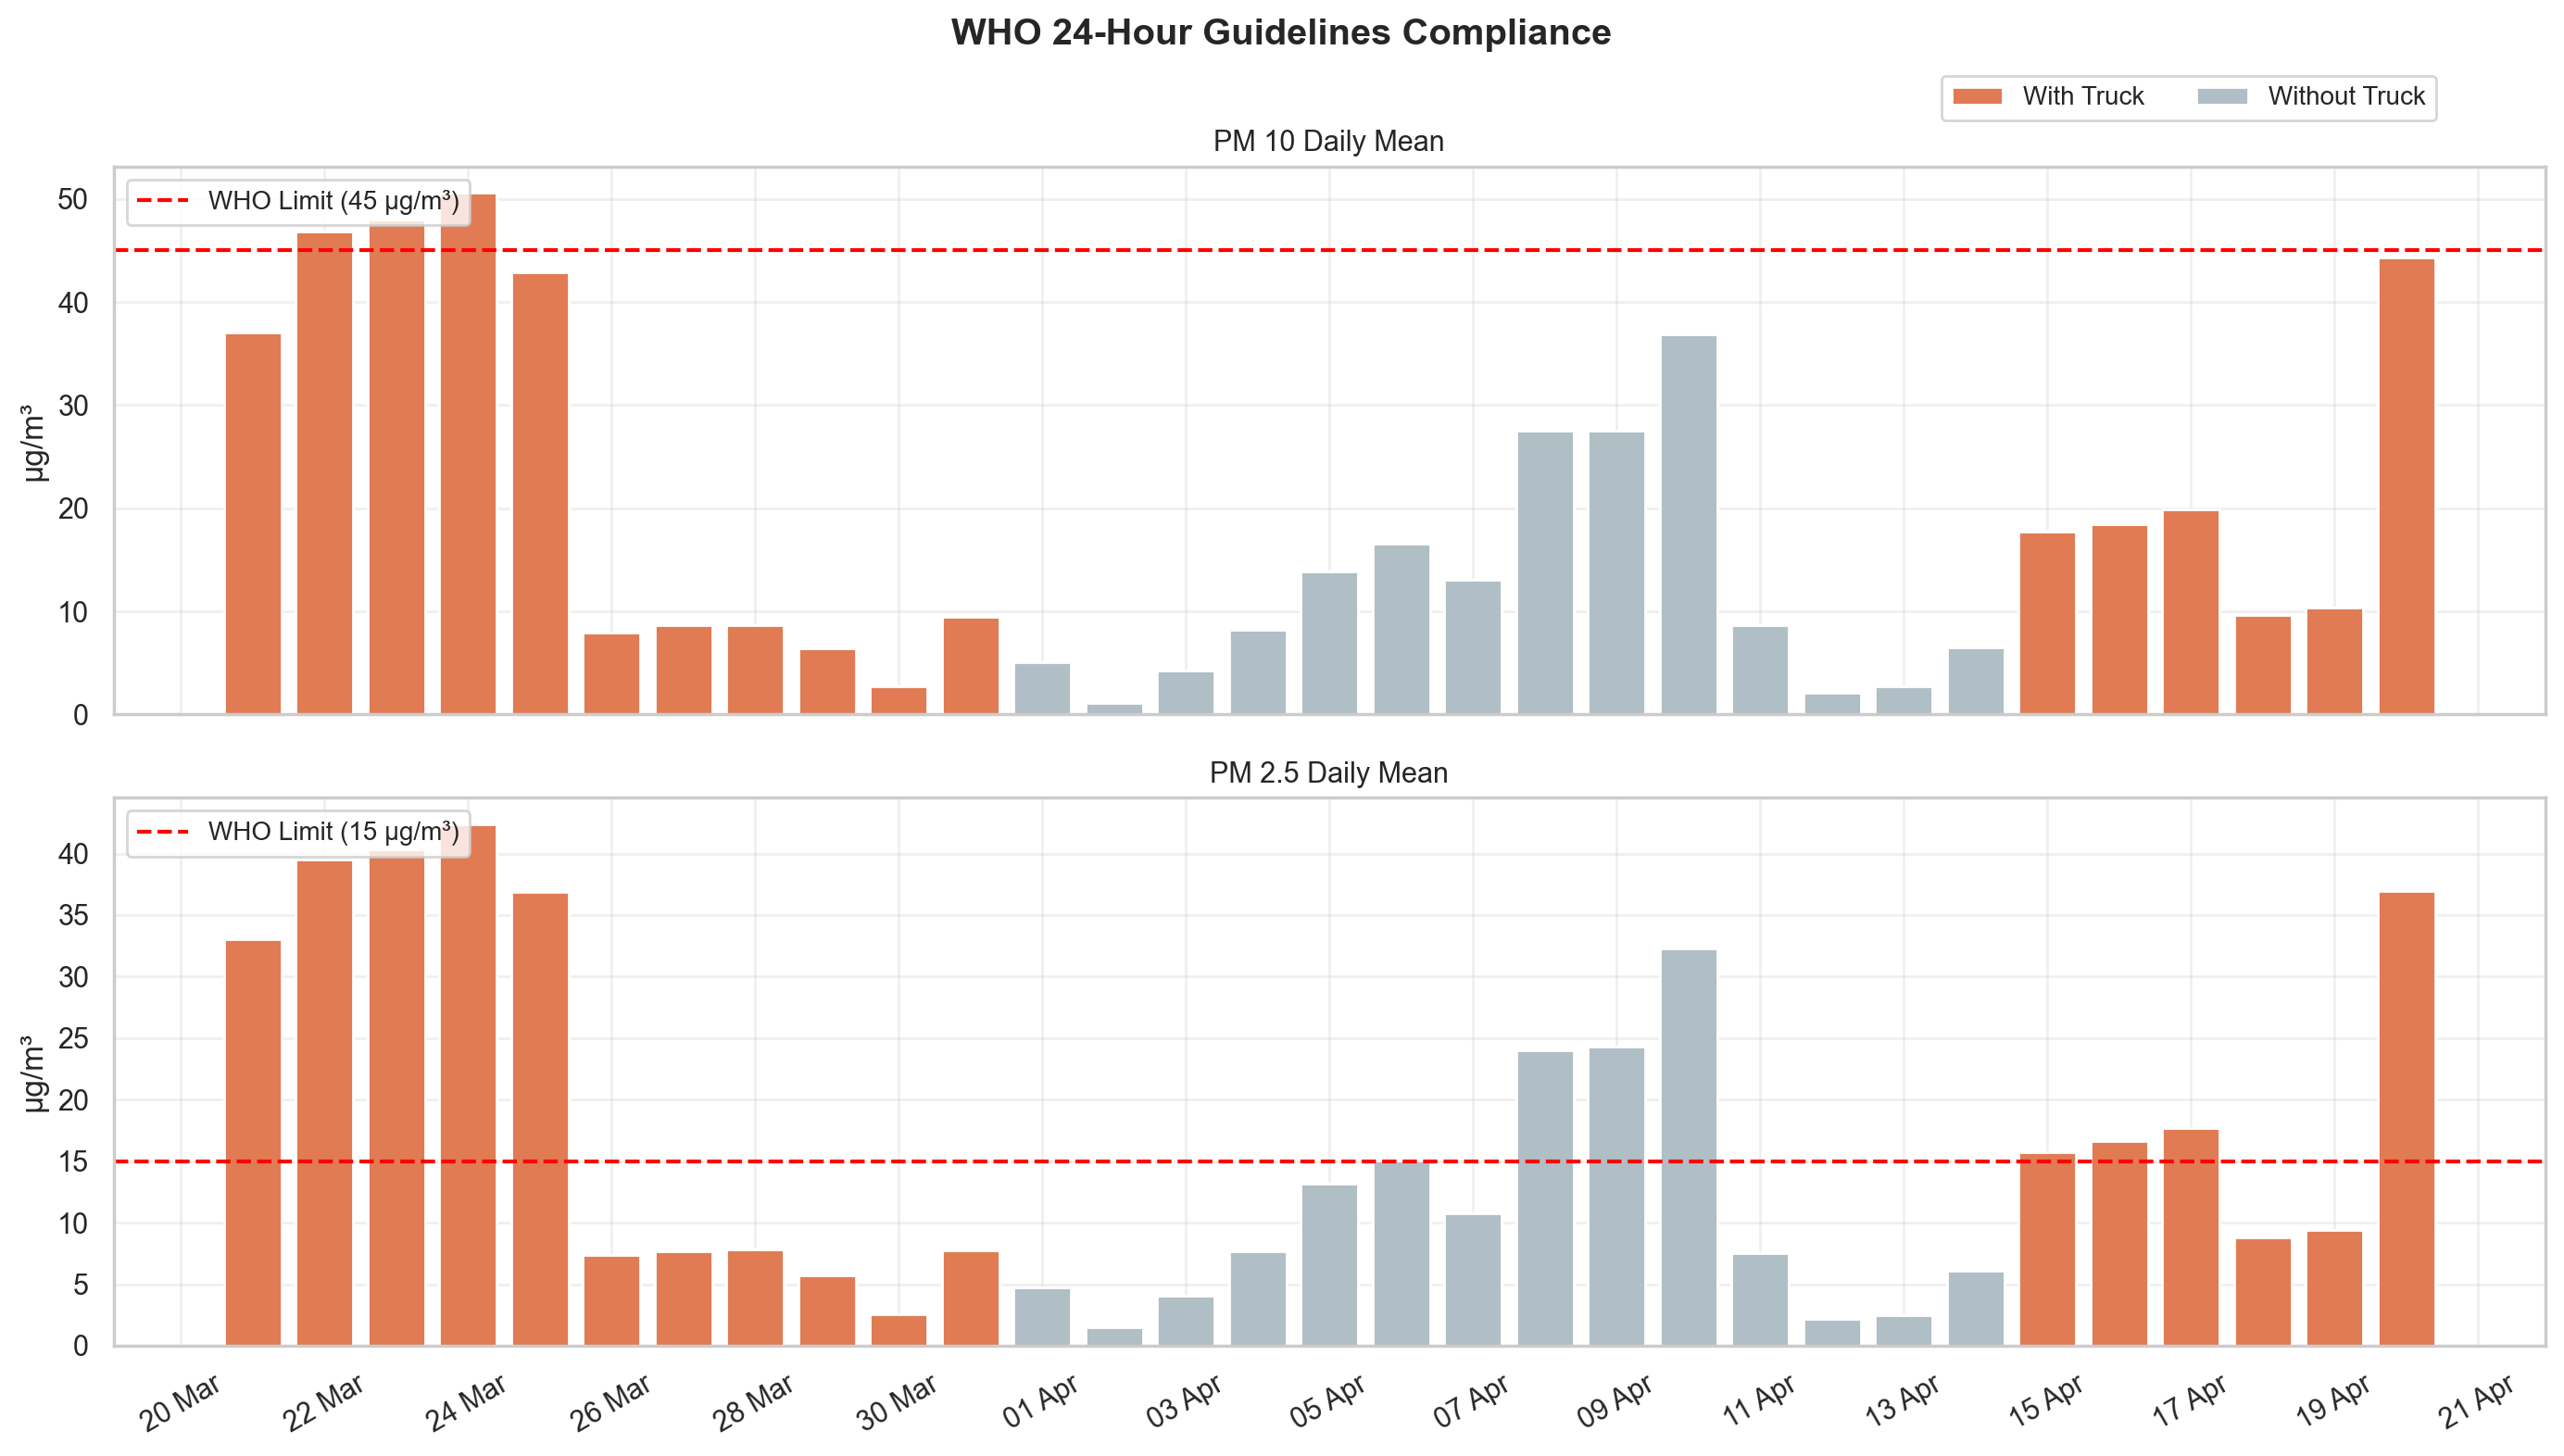

In [31]:
# 1. WHO constants
who_pm10_24h_mean = 45
who_pm25_24h_mean = 15


df_daily = df.resample('D').agg({
    'PM10_ugm3': 'mean',
    'PM25_ugm3': 'mean',
    'Truck_Presence': 'max'  # 1 si hubo camión en algún momento de ese día, 0 si no
}).dropna()

infra_pm10_camion = len(df_daily[(df_daily['PM10_ugm3'] > who_pm10_24h_mean) & (df_daily['Truck_Presence'] == 1)])
infra_pm10_sin_camion = len(df_daily[(df_daily['PM10_ugm3'] > who_pm10_24h_mean) & (df_daily['Truck_Presence'] == 0)])
infra_pm25_camion = len(df_daily[(df_daily['PM25_ugm3'] > who_pm25_24h_mean) & (df_daily['Truck_Presence'] == 1)])
infra_pm25_sin_camion = len(df_daily[(df_daily['PM25_ugm3'] > who_pm25_24h_mean) & (df_daily['Truck_Presence'] == 0)])

print("WHO Violations Report (Days):")
print(f"PM 10 (>45) WITH truck: {infra_pm10_camion} | WITHOUT truck: {infra_pm10_sin_camion}")
print(f"PM 2.5 (>15) WITH truck: {infra_pm25_camion} | WITHOUT truck: {infra_pm25_sin_camion}")
print("-" * 50)


mask_truck = df_daily['Truck_Presence'] == 1
mask_no_truck = df_daily['Truck_Presence'] == 0

color_truck = '#E07B54'
color_no_truck = '#B0BEC5'

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('WHO 24-Hour Guidelines Compliance', fontweight='bold')

# --- Eje 0: PM10 ---
axes[0].bar(df_daily[mask_truck].index, df_daily[mask_truck]['PM10_ugm3'], color=color_truck, width=0.8)
axes[0].bar(df_daily[mask_no_truck].index, df_daily[mask_no_truck]['PM10_ugm3'], color=color_no_truck, width=0.8)
axes[0].axhline(who_pm10_24h_mean, color='red', linestyle='--', linewidth=1.5, label=f'WHO Limit ({who_pm10_24h_mean} µg/m³)')
axes[0].set_title('PM 10 Daily Mean', fontsize=11)
axes[0].set_ylabel('µg/m³')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(loc='upper left')


axes[1].bar(df_daily[mask_truck].index, df_daily[mask_truck]['PM25_ugm3'], color=color_truck, width=0.8)
axes[1].bar(df_daily[mask_no_truck].index, df_daily[mask_no_truck]['PM25_ugm3'], color=color_no_truck, width=0.8)
axes[1].axhline(who_pm25_24h_mean, color='red', linestyle='--', linewidth=1.5, label=f'WHO Limit ({who_pm25_24h_mean} µg/m³)')
axes[1].set_title('PM 2.5 Daily Mean', fontsize=11)
axes[1].set_ylabel('µg/m³')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(loc='upper left')

# Formateo del Eje Temporal (X)
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].tick_params(axis='x', rotation=30)

# Leyenda Global de Estado Operativo
handles = [
    Patch(facecolor=color_truck, label='With Truck'),
    Patch(facecolor=color_no_truck, label='Without Truck')
]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.95, 0.95), ncol=2)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig('outputs/graphs/who_compliance_daily.png', dpi=200, bbox_inches='tight')
plt.show()

### 10.4.2 Regulatory Compliance: WHO 24-Hour Thresholds

The aggregation of telemetric data into daily 24-hour periods allows for a strict legal and health-based assessment against World Health Organization (WHO) guidelines.

- **PM10 (45 µg/m³ Limit):** Regulatory violations are exclusively coupled with heavy vehicle presence. However, truck presence alone is not the sole driver; non-compliance is strictly isolated to a specific, high-intensity operational event (March 21-25). Outside of this acute window, the facility operates safely below the WHO threshold over 90% of the time, even during active workshop days.
- **PM2.5 (15 µg/m³ Limit):** Fine particulate matter mirrors the structural timeline of PM10 violations. Due to the stricter regulatory threshold, the magnitude of the breach during the March operational spike is proportionally more severe, underscoring the health risks of fine particulate suspension.
- **Operational Reality:** Truck presence is a *necessary but not sufficient* condition for a WHO violation. Standard daily maintenance does not trigger threshold breaches. The telemetry isolates specific, intensive procedures (e.g., heavy grinding or exhaust testing) executed solely during the March event as the true root cause of critical atmospheric degradation.

## 11 Rank-Based Correlation Analysis (Spearman)

To mathematically quantify the multidimensional relationships between operational flags, meteorological catalysts, and emission targets, a correlation matrix is deployed. 

**Methodological Selection (Spearman vs. Pearson):** The Spearman rank-order correlation coefficient is selected over Pearson. This decision is critical because environmental telemetry frequently exhibits severe non-linear spikes (e.g., the acute 16,000 ppb VOC outliers) which distort Pearson's linear sensitivity. Furthermore, Spearman is mathematically robust when evaluating continuous variables (Temperature) against discrete operational flags (`Truck_Presence`), measuring monotonic relationships without assuming a normal distribution.

In [32]:
df['Truck_Presence'] = df['Truck_Presence'].astype(int) # It was boolean
cols_numericas = df.select_dtypes(include=np.number).columns

corr_pearson  = df[cols_numericas].corr(method='pearson')
corr_spearman = df[cols_numericas].corr(method='spearman')

print(f"Corr Pearson: {corr_pearson}\nCorr Spearman: {corr_spearman}")

Corr Pearson:                 PM10_ugm3  PM25_ugm3   VOC_ppb  Wind_Speed_kmH  Temperature_º  \
PM10_ugm3        1.000000   0.998089  0.421131       -0.252983       0.042889   
PM25_ugm3        0.998089   1.000000  0.415306       -0.258967       0.040017   
VOC_ppb          0.421131   0.415306  1.000000       -0.348242      -0.134260   
Wind_Speed_kmH  -0.252983  -0.258967 -0.348242        1.000000       0.107479   
Temperature_º    0.042889   0.040017 -0.134260        0.107479       1.000000   
Humidity_%       0.133980   0.144836  0.167356       -0.160268      -0.704457   
Rain_mmh         0.269743   0.252821  0.239833        0.051467       0.281474   
Truck_Presence   0.265575   0.258456 -0.081026       -0.172379      -0.252839   
Easter_Holiday  -0.243126  -0.235172  0.003404        0.028777      -0.019731   

                Humidity_%  Rain_mmh  Truck_Presence  Easter_Holiday  
PM10_ugm3         0.133980  0.269743        0.265575       -0.243126  
PM25_ugm3         0.144836  0.252

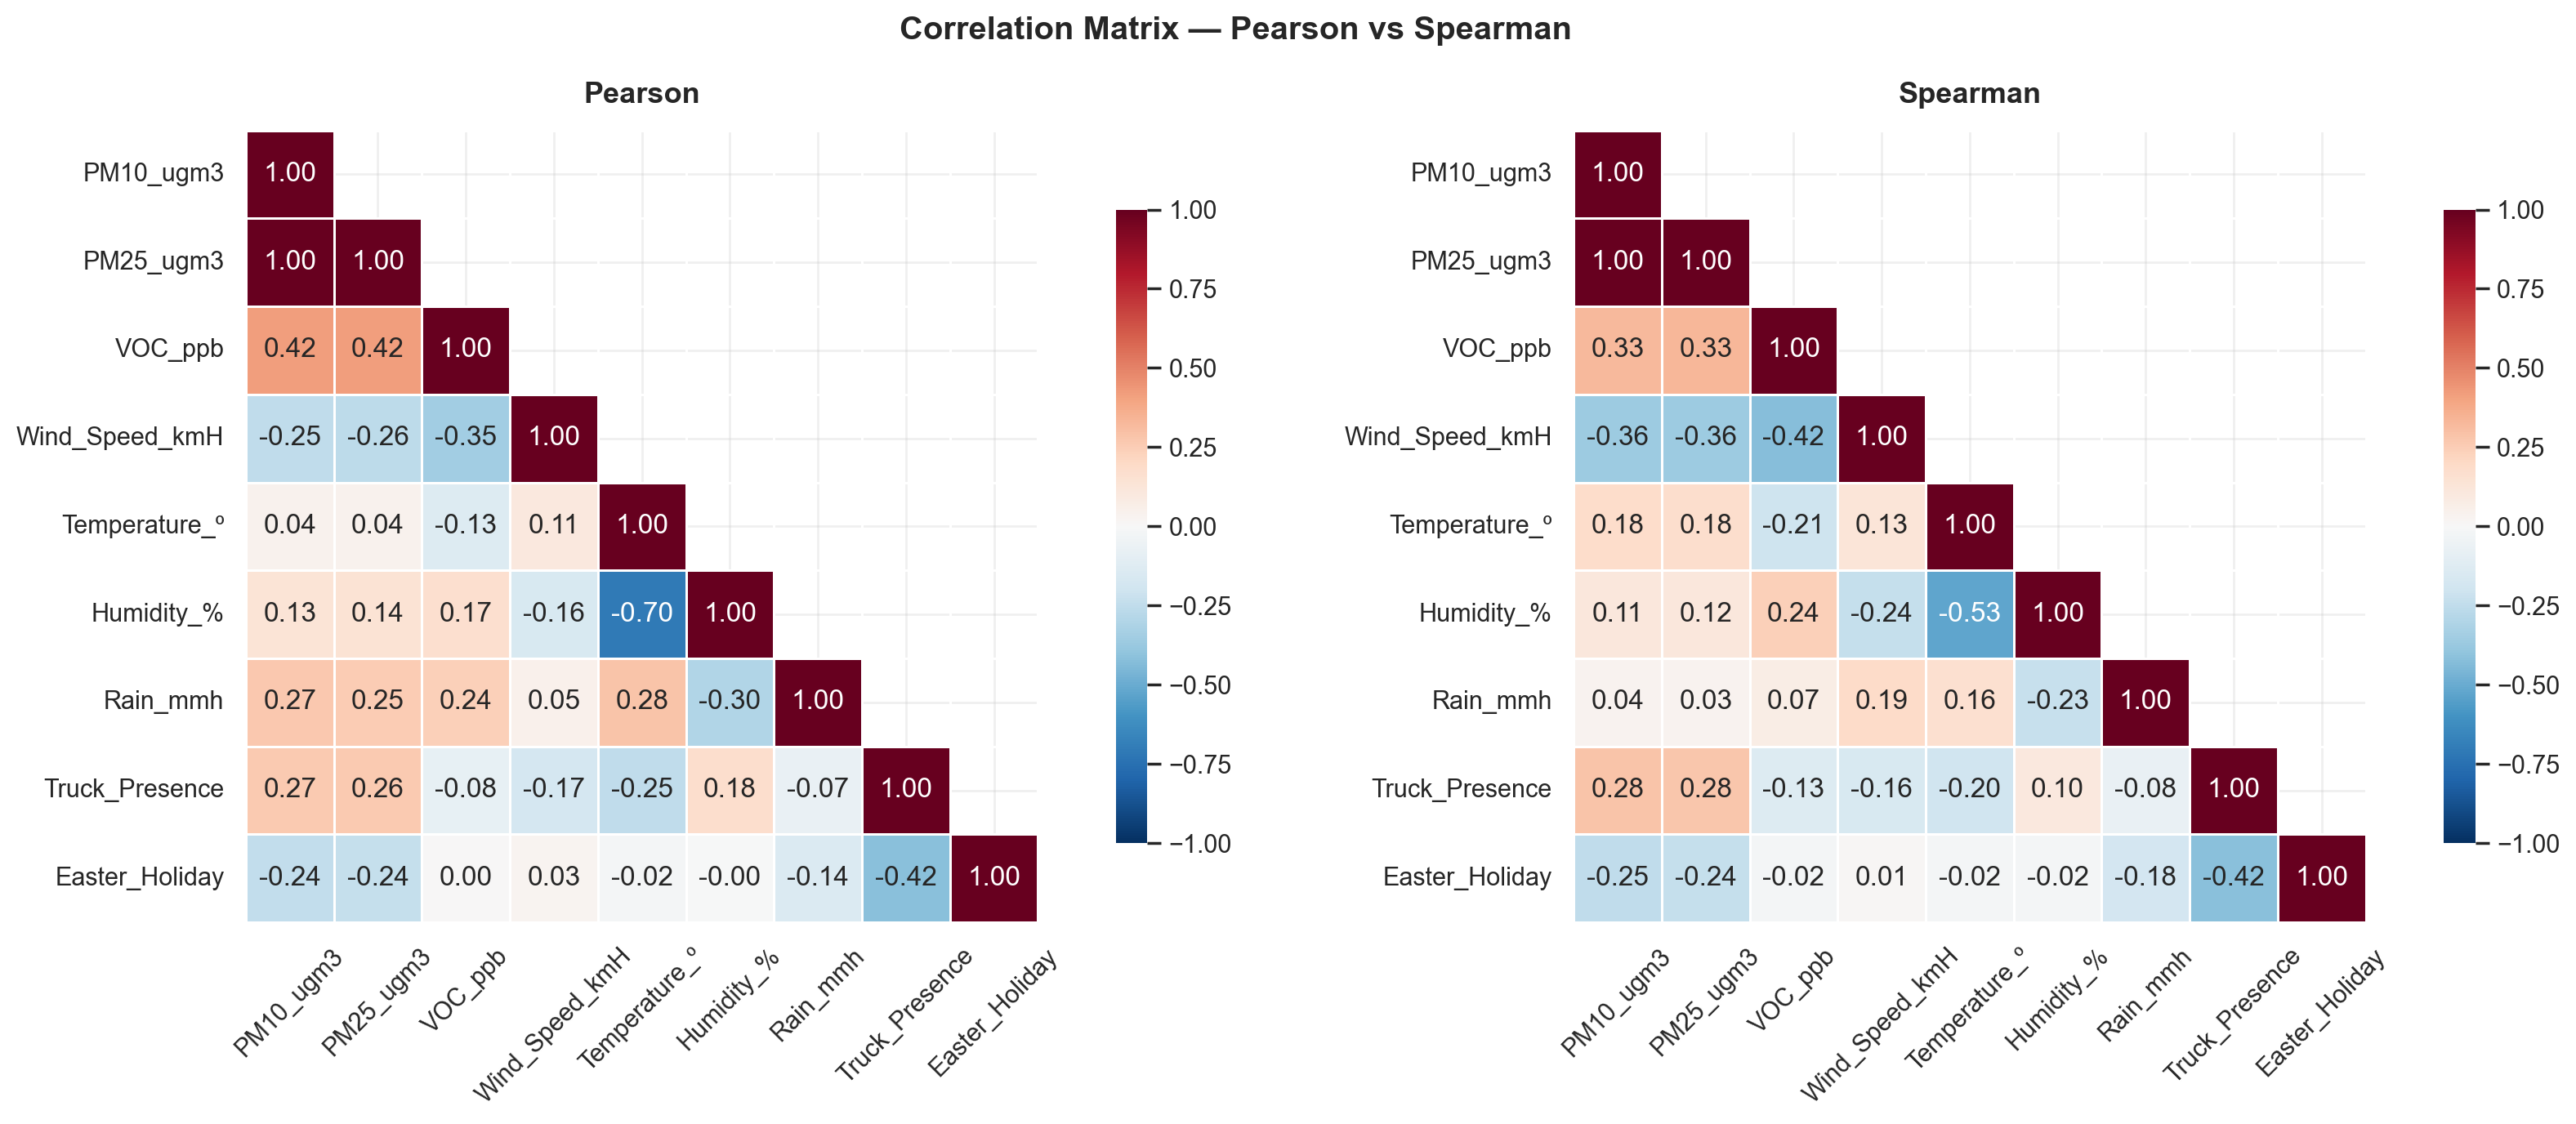

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Correlation Matrix — Pearson vs Spearman', fontweight='bold')

for ax, corr, titulo in zip(
    axes,
    [corr_pearson, corr_spearman],
    ['Pearson', 'Spearman']
):
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # solo esta línea

    sns.heatmap(
        corr, ax=ax,
        mask=mask,
        annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('outputs/graphs/correlation_pearson_spearman.png', dpi=200, bbox_inches='tight')
plt.show()

### Correlation Diagnostics

1. **The Particulate-Operational Coupling:** - `PM10` and `PM2.5` maintain a near-perfect collinearity (`0.998`), confirming they operate as a single physical entity. 
   - Both metrics exhibit a positive correlation with `Truck_Presence` (`~0.28`). While seemingly moderate, in atmospheric data, a consistent 0.28 correlation with a single operational flag validates the truck's role as a baseline multiplier.
   - Conversely, they show a negative correlation with `Easter_Holiday` (`~ -0.24`), confirming the workshop's inactivity leads to a direct drop in particulates.

2. **The Volatile Decoupling:** - `VOC` shows a negative correlation with `Truck_Presence` (`-0.13`) and a near-zero relationship with `Easter_Holiday`. This definitively shatters the assumption that standard truck maintenance drives VOC emissions. The primary driver is external.

3. **Meteorological Suppression (Wind):** - Wind Speed acts as a strong atmospheric scrubber. It holds the strongest negative correlation across all targets: `PM10` (`-0.36`) and `VOC` (`-0.42`). As wind speed increases, mechanical dispersion forces the concentration vectors down immediately.

4. **Thermodynamic Anomalies:**
   - The relationship between `VOC` and `Temperature` registers as slightly negative (`-0.20`), contrary to standard thermodynamic expectations (where heat drives volatilization). This anomaly suggests that temperature is heavily confounded by another variable (likely wind speed or specific diurnal cycles) that requires isolated testing, or that the dominant VOC source is purely combustive (traffic exhaust) rather than evaporative.

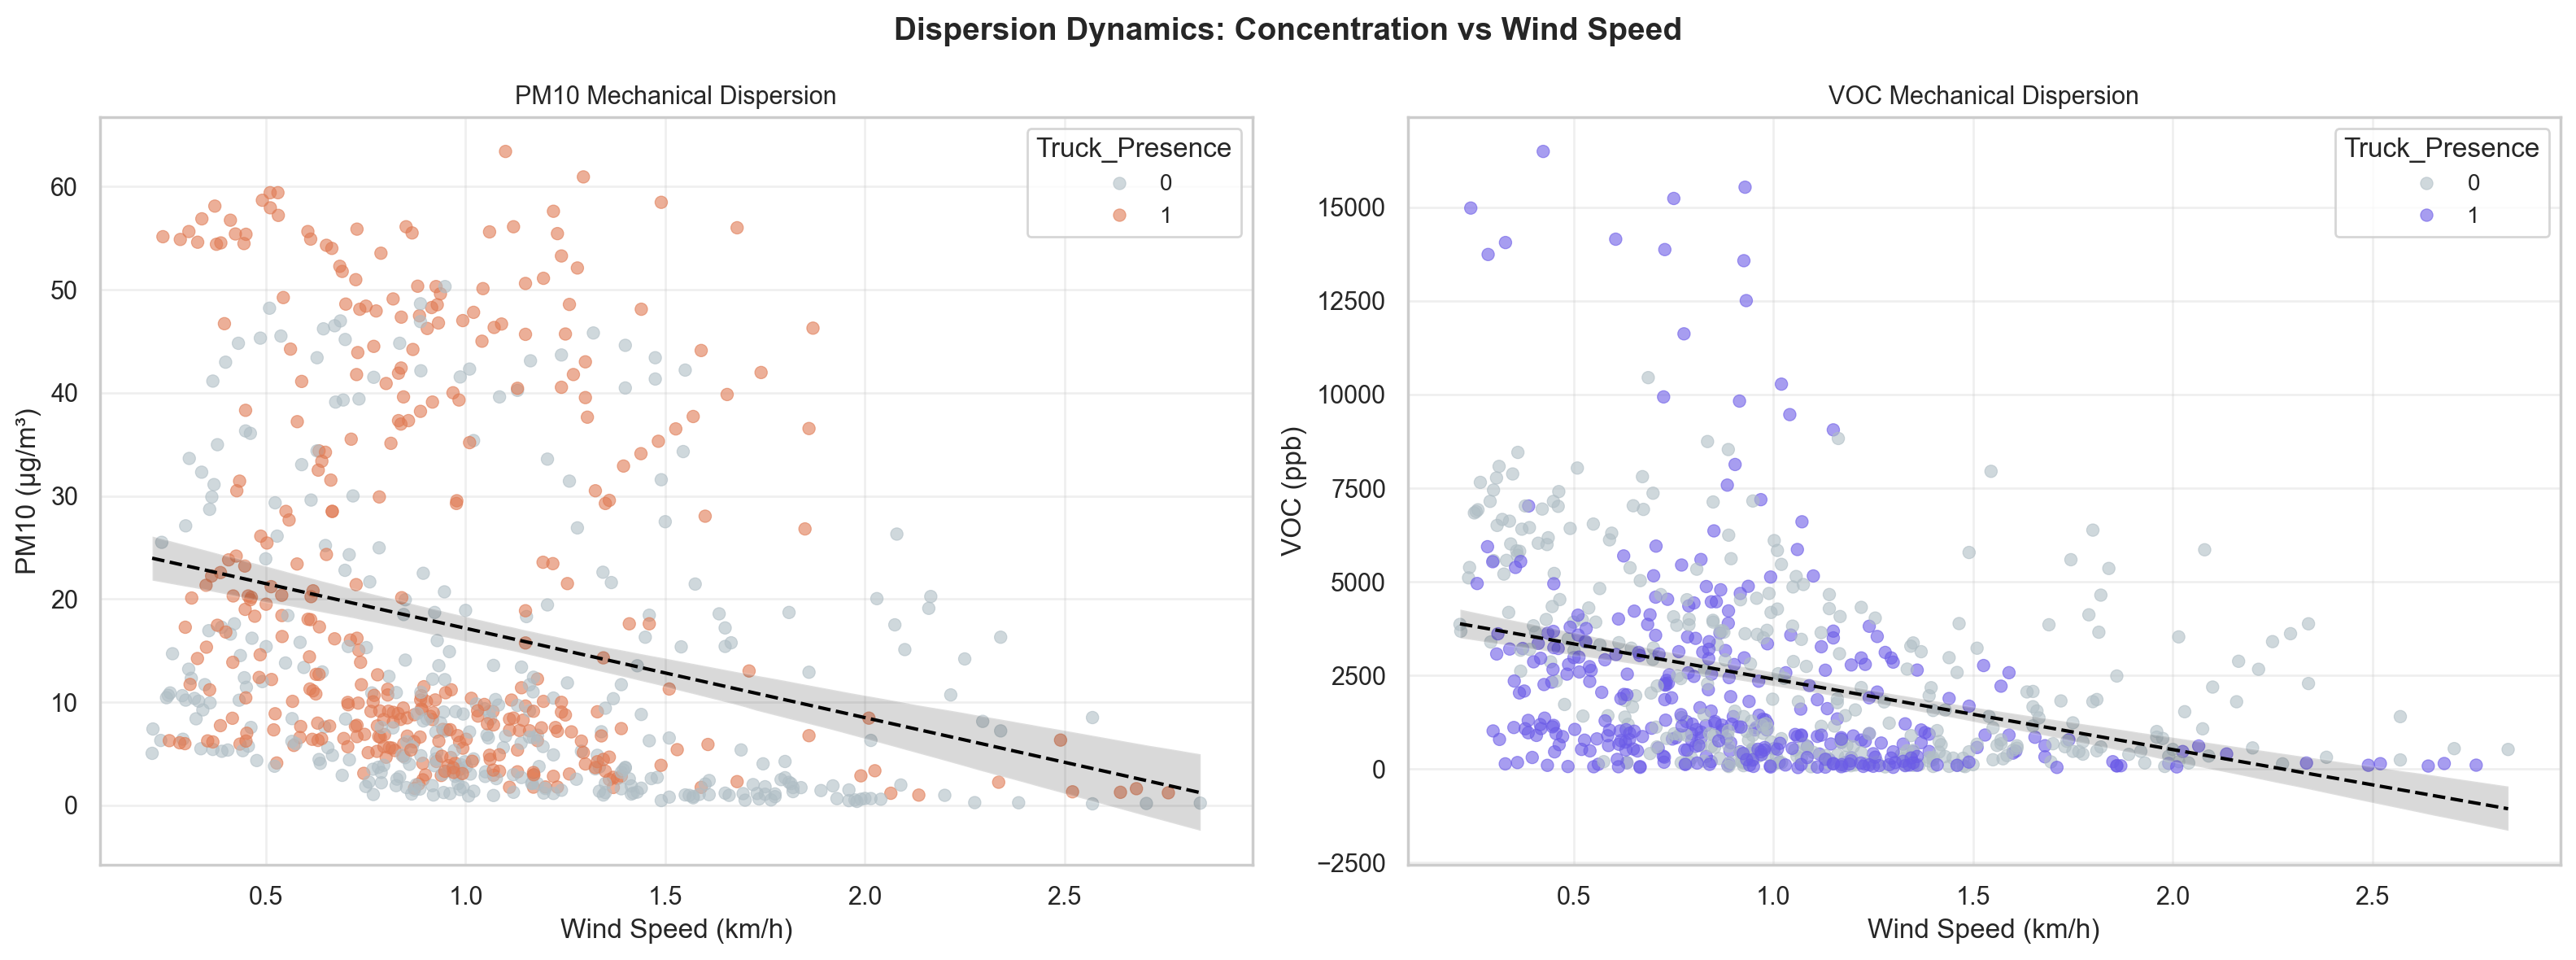

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dispersion Dynamics: Concentration vs Wind Speed', fontweight='bold', fontsize=14)

# Eje 0: PM10
sns.scatterplot(
    data=df, x='Wind_Speed_kmH', y='PM10_ugm3', hue='Truck_Presence', ax=axes[0],
    palette={True: '#E07B54', False: '#B0BEC5'}, alpha=0.6, edgecolor=None, s=30
)
sns.regplot(
    data=df, x='Wind_Speed_kmH', y='PM10_ugm3', ax=axes[0],
    scatter=False, color='black', line_kws={'linestyle': '--', 'linewidth': 1.5}
)
axes[0].set_title('PM10 Mechanical Dispersion', fontsize=11)
axes[0].set_xlabel('Wind Speed (km/h)')
axes[0].set_ylabel('PM10 (µg/m³)')
axes[0].grid(axis='both', alpha=0.3)

# Eje 1: VOC
sns.scatterplot(
    data=df, x='Wind_Speed_kmH', y='VOC_ppb', hue='Truck_Presence', ax=axes[1],
    palette={True: '#6C5CE7', False: '#B0BEC5'}, alpha=0.6, edgecolor=None, s=30
)
sns.regplot(
    data=df, x='Wind_Speed_kmH', y='VOC_ppb', ax=axes[1],
    scatter=False, color='black', line_kws={'linestyle': '--', 'linewidth': 1.5}
)
axes[1].set_title('VOC Mechanical Dispersion', fontsize=11)
axes[1].set_xlabel('Wind Speed (km/h)')
axes[1].set_ylabel('VOC (ppb)')
axes[1].grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/graphs/scatter_wind_speed.png', dpi=200, bbox_inches='tight')
plt.show()

### 11.2 Mechanical Dispersion Dynamics: Wind Speed vs. Concentration

The scatter plot, augmented with a mathematical regression vector, demonstrates the mechanical dilution effect of wind on local pollutant exposure. 

#### Architectural Insights:

- **The Asymptotic Boundary (L-Curve Effect):** Both PM10 and VOC distributions display a strict, non-linear geometric boundary. Critical accumulation peaks—regardless of operational status—are physically constrained to periods of atmospheric stagnation (Wind Speed < 10–15 km/h). 
- **The Dilution Threshold:** As wind speed surpasses the 15 km/h threshold, the atmospheric boundary layer mixes forcefully. Beyond this point, the maximum potential concentration collapses to a baseline minimum, effectively neutralizing the operational multiplier effect of heavy vehicle maintenance (`Truck_Presence`).
- **Regression Confirmation:** The negative mathematical trendlines visually corroborate the inverse relationships detected in the Spearman matrix. Wind speed does not halt emission generation at the source, but it acts as an aggressive mechanical scrubber, preventing localized toxic accumulation and ensuring regulatory compliance during high-wind intervals.

## 12. Final Conclusions and Executive Summary

The exploratory and diagnostic analysis of the environmental telemetry establishes the following structural determinations regarding the commercial vehicle workshop's impact on local air quality:

### 1. Particulate Vector (PM10 and PM2.5): Conditioned Operational Multiplier
Particulate matter emission is coupled with workshop activity. The `Truck_Presence` variable operates as a direct multiplier of the baseline concentration. Heavy vehicle presence is a necessary, but not sufficient, condition to trigger environmental alerts. The high variance and the existence of operational days with minimal PM levels demonstrate that critical atmospheric degradation does not stem from standard vehicle maintenance, but from the execution of specific, high-intensity industrial operations (e.g., intensive grinding or engine testing).

### 2. Chemical Vector (VOC): Operational Decoupling and External Dominance
Volatile organic compounds operate independently of the workshop's workload. VOC anomalies and spikes are decoupled from truck presence at the facilities. Their behavior responds to a circadian pattern driven by external sources, specifically the traffic flow of the adjacent highway, evidenced by bimodal peaks during commuting hours. VOC concentration is parameterized by extrinsic thermodynamic factors: it is activated by temperature increases and suppressed by high levels of relative humidity.

### 3. Dispersion Dynamics and Regulatory Compliance (WHO)
Wind speed acts as the primary mechanical scrubber in the local boundary layer. At speeds exceeding the 10-15 km/h threshold, physical dispersion prevents the consolidation of toxic accumulation events. In terms of regulatory compliance against the World Health Organization (WHO), the facility operates below the 24-hour safety thresholds for over 90% of the active working time. Recorded regulatory infractions are isolated events requiring the simultaneous intersection of an exceptional operational emission peak and atmospheric stagnation conditions.